## **-- Main PIP --**

In [1]:
import random
import json
import time
import json
import sys
import os

**== Parsing ==**

# USER-AGENT

In [2]:
CATEGORIES = {
    "tablets": "https://ozon.kz/category/planshety-15525/",
    "smartphones": "https://ozon.kz/category/smartfony-15502/",
    "laptop": "https://ozon.kz/category/noutbuki-15692/"
}

cookies = {
    '__Secure-ETC': 'f046a6a9c58936acfd32c6028e96e074',
    'abt_data': '7.Y8MSzSbCE3HjOYSZsz0AqiWpnk564PMaBrF98wqABeAX4aznWzzKB7spx8s8BXiRlUSXlyw1JQdGZuZexx0WHxDXfZbaeKIcy7sP1gR4FeaLs3PK0_t7kHtqHg12Rce1SkIcuNytbMxj27QFy_IA_ReJXS8bH6Auxc-0OIAuABnNMzPG1yBBgCaoMCqqvngswmo1aE0Nrz9_jO_Eda8zB_tlFsHwMDbqlmoR6W2voO7T-qRFSoFZdfaxMf4v04ygxYpEVDq05VkYSOSC_sTYzFseBiZZiVk3RuoK1aZhq9t5GDftUlyvDy22qp1ShkXUjAupg2k7EP1-b0tp3J45fInvU9Q-IJkXQWnlm2VBD4ffeKAHC068uf3LEMsiB_oz72thed7BG5k2ePf-put84hUCGLkfdFDEUSOHxKITk-GqiIR9fY6yTDz0sC7F5DmvIFOBZZertQzz_hv0NdQCNqICZ5clGesK8dn9dPQTUNvv0L4nLczqaR8USbP8ow-uP3q56azR778-TWjG07HMQTxm6NES03yDzz0Zlsv6HNfebOCjDiQRfkVc60TTytbjsAE3F3Y5YB_jothujNnc2_HGi02h_urXj3LM_CRbzkxhf98DDtbGMGVmEUCHsBd1nE-G-77XevPfmRG73fxt6ji7PFCPUA',
    '__Secure-access-token': '12.0.UOgEFywAT6W9-bLLh7Srug.37.ARnEnvVsZGLSfTi_ZejTfXr40ZJq2jvPun5PkGQPNhjd0d-xXprIS3AB-XOmqZe5i6QywhBMr073NB24xHC7pJXOgl5v5H1-aTJz-ZIAJcgEVL0IgMeSUlfyGsu_EQRkiA..20260420132548.2._BEYtYUIEnEWQ5oOxqQS5jHjfo0pWIHrvWshEZIuaTI.178789bb35eaa45ba',
    '__Secure-refresh-token': '12.0.UOgEFywAT6W9-bLLh7Srug.37.ARnEnvVsZGLSfTi_ZejTfXr40ZJq2jvPun5PkGQPNhjd0d-xXprIS3AB-XOmqZe5i6QywhBMr073NB24xHC7pJXOgl5v5H1-aTJz-ZIAJcgEVL0IgMeSUlfyGsu_EQRkiA..20260420132548.2.CtWQZvQ6FYdbM-k7eL7Js-IvWz-ui-hQT6BcmH59BCU.1ff473a920b50c7a2',
    '__Secure-ab-group': '37',
    '__Secure-user-id': '0',
    '__Secure-ext_xcid': '96ffbfbb66dfebfb97a1079bea72f507',
    'ADDRESSBOOKBAR_WEB_CLARIFICATION': '1776589293',
    'rfuid': 'LTE5NTAyNjU0NzAsMzUuNzQ5OTcyMDkzODUwMzc0LDEzNzAwNjM5MTUsV2luZG93cyBOVCAxMC4wOyBXaW42NDsgeDY0LC04MjMzNTcwNjMsVzNzaWJtRnRaU0k2SWxCRVJpQldhV1YzWlhJaUxDSmtaWE5qY21sd2RHbHZiaUk2SWxCdmNuUmhZbXhsSUVSdlkzVnRaVzUwSUVadmNtMWhkQ0lzSW0xcGJXVlVlWEJsY3lJNlczc2lkSGx3WlNJNkltRndjR3hwWTJGMGFXOXVMM0JrWmlJc0luTjFabVpwZUdWeklqb2ljR1JtSW4wc2V5SjBlWEJsSWpvaWRHVjRkQzl3WkdZaUxDSnpkV1ptYVhobGN5STZJbkJrWmlKOVhYMHNleUp1WVcxbElqb2lRMmh5YjIxbElGQkVSaUJXYVdWM1pYSWlMQ0prWlhOamNtbHdkR2x2YmlJNklsQnZjblJoWW14bElFUnZZM1Z0Wlc1MElFWnZjbTFoZENJc0ltMXBiV1ZVZVhCbGN5STZXM3NpZEhsd1pTSTZJbUZ3Y0d4cFkyRjBhVzl1TDNCa1ppSXNJbk4xWm1acGVHVnpJam9pY0dSbUluMHNleUowZVhCbElqb2lkR1Y0ZEM5d1pHWWlMQ0p6ZFdabWFYaGxjeUk2SW5Ca1ppSjlYWDBzZXlKdVlXMWxJam9pUTJoeWIyMXBkVzBnVUVSR0lGWnBaWGRsY2lJc0ltUmxjMk55YVhCMGFXOXVJam9pVUc5eWRHRmliR1VnUkc5amRXMWxiblFnUm05eWJXRjBJaXdpYldsdFpWUjVjR1Z6SWpwYmV5SjBlWEJsSWpvaVlYQndiR2xqWVhScGIyNHZjR1JtSWl3aWMzVm1abWw0WlhNaU9pSndaR1lpZlN4N0luUjVjR1VpT2lKMFpYaDBMM0JrWmlJc0luTjFabVpwZUdWeklqb2ljR1JtSW4xZGZTeDdJbTVoYldVaU9pSk5hV055YjNOdlpuUWdSV1JuWlNCUVJFWWdWbWxsZDJWeUlpd2laR1Z6WTNKcGNIUnBiMjRpT2lKUWIzSjBZV0pzWlNCRWIyTjFiV1Z1ZENCR2IzSnRZWFFpTENKdGFXMWxWSGx3WlhNaU9sdDdJblI1Y0dVaU9pSmhjSEJzYVdOaGRHbHZiaTl3WkdZaUxDSnpkV1ptYVhobGN5STZJbkJrWmlKOUxIc2lkSGx3WlNJNkluUmxlSFF2Y0dSbUlpd2ljM1ZtWm1sNFpYTWlPaUp3WkdZaWZWMTlMSHNpYm1GdFpTSTZJbGRsWWt0cGRDQmlkV2xzZEMxcGJpQlFSRVlpTENKa1pYTmpjbWx3ZEdsdmJpSTZJbEJ2Y25SaFlteGxJRVJ2WTNWdFpXNTBJRVp2Y20xaGRDSXNJbTFwYldWVWVYQmxjeUk2VzNzaWRIbHdaU0k2SW1Gd2NHeHBZMkYwYVc5dUwzQmtaaUlzSW5OMVptWnBlR1Z6SWpvaWNHUm1JbjBzZXlKMGVYQmxJam9pZEdWNGRDOXdaR1lpTENKemRXWm1hWGhsY3lJNkluQmtaaUo5WFgxZCxXeUp5ZFMxU1ZTSXNJbkoxTFZKVklpd2ljblVpTENKbGJpMVZVeUlzSW1WdUlsMD0sMCwxLDAsMjQsMjM3NDE1OTMwLC0xLDIyNzEyNjUyMCwwLDEsMCwtNDkxMjc1NTIzLElFNWxkSE5qWVhCbElFZGxZMnR2SUZkcGJqTXlJRFV1TUNBb1YybHVaRzkzY3lrZ01qQXhNREF4TURFZ1RXOTZhV3hzWVE9PSxlMzA9LDY1LDEwMTczNDIwOCwxLDEsLTEsMTY5OTk1NDg4NywxNjk5OTU0ODg3LDMzNjAwNzkzMyw4',
    'xcid': '47d982a81021a7371e34a93ba221e23e',
    'guest': 'true',
}

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:149.0) Gecko/20100101 Firefox/149.0',
    'Accept': 'application/json',
    'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
    # 'Accept-Encoding': 'gzip, deflate, br, zstd',
    'Referer': 'https://ozon.kz/product/apple-smartfon-iphone-15-sim-esim-128-gb-siniy-1185261285/?at=6WtZgrAoJswPgP2oS287mJLHqvG7zBIl73zrRtxoY4KP',
    'x-o3-app-name': 'dweb_client',
    'x-o3-app-version': 'release_17-3-2026_ce6c79ce',
    'x-o3-manifest-version': 'frontend-ozon-ru:ce6c79cef2b7331e4395150280f540142b988351,pdp-render-api:78e197ee0d8ae5c23c94ce213be958a3008657e8,checkout-render-api:5feb5c71178296edb24e269302b89b1634a840c5,sf-render-api:95ac8be2cfc5f71340c6200f8f03b667761aeb5b,search-render-api:d8b94ab92cb85a8ae66991d36f72b7eb32f069bb,fav-render-api:98a701174a7f5f23dff57e880f2c6fdf76ab5a5a',
    'x-o3-parent-requestid': '58d82b8787ef926b56109e6233582ae1',
    'x-page-view-id': 'ec2628d9-8353-4374-c744-82007ecf7d18',
    'x-page-previous': 'category',
    'Content-Type': 'application/json',
    'Connection': 'keep-alive',
    # 'Cookie': '__Secure-ETC=f046a6a9c58936acfd32c6028e96e074; abt_data=7.Y8MSzSbCE3HjOYSZsz0AqiWpnk564PMaBrF98wqABeAX4aznWzzKB7spx8s8BXiRlUSXlyw1JQdGZuZexx0WHxDXfZbaeKIcy7sP1gR4FeaLs3PK0_t7kHtqHg12Rce1SkIcuNytbMxj27QFy_IA_ReJXS8bH6Auxc-0OIAuABnNMzPG1yBBgCaoMCqqvngswmo1aE0Nrz9_jO_Eda8zB_tlFsHwMDbqlmoR6W2voO7T-qRFSoFZdfaxMf4v04ygxYpEVDq05VkYSOSC_sTYzFseBiZZiVk3RuoK1aZhq9t5GDftUlyvDy22qp1ShkXUjAupg2k7EP1-b0tp3J45fInvU9Q-IJkXQWnlm2VBD4ffeKAHC068uf3LEMsiB_oz72thed7BG5k2ePf-put84hUCGLkfdFDEUSOHxKITk-GqiIR9fY6yTDz0sC7F5DmvIFOBZZertQzz_hv0NdQCNqICZ5clGesK8dn9dPQTUNvv0L4nLczqaR8USbP8ow-uP3q56azR778-TWjG07HMQTxm6NES03yDzz0Zlsv6HNfebOCjDiQRfkVc60TTytbjsAE3F3Y5YB_jothujNnc2_HGi02h_urXj3LM_CRbzkxhf98DDtbGMGVmEUCHsBd1nE-G-77XevPfmRG73fxt6ji7PFCPUA; __Secure-access-token=12.0.UOgEFywAT6W9-bLLh7Srug.37.ARnEnvVsZGLSfTi_ZejTfXr40ZJq2jvPun5PkGQPNhjd0d-xXprIS3AB-XOmqZe5i6QywhBMr073NB24xHC7pJXOgl5v5H1-aTJz-ZIAJcgEVL0IgMeSUlfyGsu_EQRkiA..20260420132548.2._BEYtYUIEnEWQ5oOxqQS5jHjfo0pWIHrvWshEZIuaTI.178789bb35eaa45ba; __Secure-refresh-token=12.0.UOgEFywAT6W9-bLLh7Srug.37.ARnEnvVsZGLSfTi_ZejTfXr40ZJq2jvPun5PkGQPNhjd0d-xXprIS3AB-XOmqZe5i6QywhBMr073NB24xHC7pJXOgl5v5H1-aTJz-ZIAJcgEVL0IgMeSUlfyGsu_EQRkiA..20260420132548.2.CtWQZvQ6FYdbM-k7eL7Js-IvWz-ui-hQT6BcmH59BCU.1ff473a920b50c7a2; __Secure-ab-group=37; __Secure-user-id=0; __Secure-ext_xcid=96ffbfbb66dfebfb97a1079bea72f507; ADDRESSBOOKBAR_WEB_CLARIFICATION=1776589293; rfuid=LTE5NTAyNjU0NzAsMzUuNzQ5OTcyMDkzODUwMzc0LDEzNzAwNjM5MTUsV2luZG93cyBOVCAxMC4wOyBXaW42NDsgeDY0LC04MjMzNTcwNjMsVzNzaWJtRnRaU0k2SWxCRVJpQldhV1YzWlhJaUxDSmtaWE5qY21sd2RHbHZiaUk2SWxCdmNuUmhZbXhsSUVSdlkzVnRaVzUwSUVadmNtMWhkQ0lzSW0xcGJXVlVlWEJsY3lJNlczc2lkSGx3WlNJNkltRndjR3hwWTJGMGFXOXVMM0JrWmlJc0luTjFabVpwZUdWeklqb2ljR1JtSW4wc2V5SjBlWEJsSWpvaWRHVjRkQzl3WkdZaUxDSnpkV1ptYVhobGN5STZJbkJrWmlKOVhYMHNleUp1WVcxbElqb2lRMmh5YjIxbElGQkVSaUJXYVdWM1pYSWlMQ0prWlhOamNtbHdkR2x2YmlJNklsQnZjblJoWW14bElFUnZZM1Z0Wlc1MElFWnZjbTFoZENJc0ltMXBiV1ZVZVhCbGN5STZXM3NpZEhsd1pTSTZJbUZ3Y0d4cFkyRjBhVzl1TDNCa1ppSXNJbk4xWm1acGVHVnpJam9pY0dSbUluMHNleUowZVhCbElqb2lkR1Y0ZEM5d1pHWWlMQ0p6ZFdabWFYaGxjeUk2SW5Ca1ppSjlYWDBzZXlKdVlXMWxJam9pUTJoeWIyMXBkVzBnVUVSR0lGWnBaWGRsY2lJc0ltUmxjMk55YVhCMGFXOXVJam9pVUc5eWRHRmliR1VnUkc5amRXMWxiblFnUm05eWJXRjBJaXdpYldsdFpWUjVjR1Z6SWpwYmV5SjBlWEJsSWpvaVlYQndiR2xqWVhScGIyNHZjR1JtSWl3aWMzVm1abWw0WlhNaU9pSndaR1lpZlN4N0luUjVjR1VpT2lKMFpYaDBMM0JrWmlJc0luTjFabVpwZUdWeklqb2ljR1JtSW4xZGZTeDdJbTVoYldVaU9pSk5hV055YjNOdlpuUWdSV1JuWlNCUVJFWWdWbWxsZDJWeUlpd2laR1Z6WTNKcGNIUnBiMjRpT2lKUWIzSjBZV0pzWlNCRWIyTjFiV1Z1ZENCR2IzSnRZWFFpTENKdGFXMWxWSGx3WlhNaU9sdDdJblI1Y0dVaU9pSmhjSEJzYVdOaGRHbHZiaTl3WkdZaUxDSnpkV1ptYVhobGN5STZJbkJrWmlKOUxIc2lkSGx3WlNJNkluUmxlSFF2Y0dSbUlpd2ljM1ZtWm1sNFpYTWlPaUp3WkdZaWZWMTlMSHNpYm1GdFpTSTZJbGRsWWt0cGRDQmlkV2xzZEMxcGJpQlFSRVlpTENKa1pYTmpjbWx3ZEdsdmJpSTZJbEJ2Y25SaFlteGxJRVJ2WTNWdFpXNTBJRVp2Y20xaGRDSXNJbTFwYldWVWVYQmxjeUk2VzNzaWRIbHdaU0k2SW1Gd2NHeHBZMkYwYVc5dUwzQmtaaUlzSW5OMVptWnBlR1Z6SWpvaWNHUm1JbjBzZXlKMGVYQmxJam9pZEdWNGRDOXdaR1lpTENKemRXWm1hWGhsY3lJNkluQmtaaUo5WFgxZCxXeUp5ZFMxU1ZTSXNJbkoxTFZKVklpd2ljblVpTENKbGJpMVZVeUlzSW1WdUlsMD0sMCwxLDAsMjQsMjM3NDE1OTMwLC0xLDIyNzEyNjUyMCwwLDEsMCwtNDkxMjc1NTIzLElFNWxkSE5qWVhCbElFZGxZMnR2SUZkcGJqTXlJRFV1TUNBb1YybHVaRzkzY3lrZ01qQXhNREF4TURFZ1RXOTZhV3hzWVE9PSxlMzA9LDY1LDEwMTczNDIwOCwxLDEsLTEsMTY5OTk1NDg4NywxNjk5OTU0ODg3LDMzNjAwNzkzMyw4; xcid=47d982a81021a7371e34a93ba221e23e; guest=true',
    'Sec-Fetch-Dest': 'empty',
    'Sec-Fetch-Mode': 'cors',
    'Sec-Fetch-Site': 'same-origin',
    'Priority': 'u=4',
    # Requests doesn't support trailers
    # 'TE': 'trailers',
}


Data Collection

# Parsing Links

In [3]:
import undetected_chromedriver as uc
sys.path.append(os.path.abspath(os.path.join('..')))
from src.parser.get_links import get_links_from_category

In [ ]:
all_categories_data = {}

for name, url in CATEGORIES.items():
    # options = uc.ChromeOptions()
    # options.add_argument('--blink-settings=imagesEnabled=false')
    # driver = uc.Chrome(options=options, version_main=147)
    print(f"\n🚀 Parsing links for a category: {name.upper()}")
    
    # INIT DRIVER
    
    try:
        links = get_links_from_category(url, name)
        all_categories_data[name] = links
        
        # Save each category to its own file at once.
        filename = f"{name}_urls.json"
        with open(f'data/raw/url/off/{filename}', 'w', encoding='utf-8') as f:
            json.dump(links, f, ensure_ascii=False, indent=4)
            
        print(f"✅ READY! Link {name} save in {filename}")
        
    except Exception as e:
        print(f"❌ Error in category {name}: {e}")
    
    finally:
        # Close the browser before the next iteration.
        # driver.quit()
        # A short break between categories
        time.sleep(5)

print("\n🎯 Collection of all categories is complete!")


🚀 Parsing links for a category: TABLETS


Parsing Cards

In [ ]:
sys.path.append(os.path.abspath(os.path.join('..')))
from src.parser.fetch_cards import fetch_product_data

In [ ]:
all_results = []

for current_cat in CATEGORIES.keys():
    input_file = f"data/raw/url/{current_cat}_urls.json"
    output_json = f"data/raw/categories/{current_cat}_results.json"
    
    print(f"\n--- 📂 Let's start Parsing the category: {current_cat} ---")
    
    try:
        with open(input_file, 'r', encoding='utf-8') as f:
            urls = json.load(f)
        urls_to_parse = urls 
        print(f" Total links: {len(urls_to_parse)}")
    except FileNotFoundError:
        print(f" File {input_file} not found.")
        continue

    cat_results = []
    
    for i, url in enumerate(urls_to_parse):
        data = fetch_product_data(url)
        
        if data:
            row = {
                "Category": current_cat,
                "Name": data["base_info"].get("name"),
                "Price": data["base_info"].get("price"),
                "Old Price": data["base_info"].get("old_price"),
                "Installment": data["base_info"].get("installment_price"),
                "Rating": data["base_info"].get("product_rating"),
                "Reviews": data["base_info"].get("reviews_count"),
                "Seller": data["base_info"].get("seller_name"),
                "Seller Rating": data["base_info"].get("seller_rating"),
                "URL": data["url"],
                "Characteristics": data["characteristics"]
            }
            cat_results.append(row)
            
            name_log = row['Name'][:30] if row['Name'] else "Без названия"
            print(f"[{i+1}/{len(urls_to_parse)}] ✅ {name_log}...")

         # --- AUTOSAVE ---- 
        AUTOTIMETOSAVE = 250
        if (i + 1) % AUTOTIMETOSAVE == 0 and cat_results:
            # If this is the first hundred, there is no data in the file yet.
            if (i + 1) == AUTOTIMETOSAVE:
                data_to_save = cat_results
            else:
                # We read what has already been written
                try:
                    with open(output_json, 'r', encoding='utf-8') as f:
                        data_to_save = json.load(f) + cat_results
                except:
                    data_to_save = cat_results

            with open(output_json, 'w', encoding='utf-8') as f:
                json.dump(data_to_save, f, ensure_ascii=False, indent=4)
            
            print(f"💾 Autosave: {i+1} goods recorded in {output_json}")
            
            all_results.extend(cat_results)
            cat_results = [] 
            time.sleep(random.randint(30, 60)) 

        time.sleep(random.uniform(1.7, 2.5))

    # --- ADDITIONAL RECORDING OF REMAININGS ---
    if cat_results:
        # Trying to read an existing file if parsing took a long time
        try:
            with open(output_json, 'r', encoding='utf-8') as f:
                final_data = json.load(f) + cat_results
        except:
            final_data = cat_results

        with open(output_json, 'w', encoding='utf-8') as f:
            json.dump(final_data, f, ensure_ascii=False, indent=4)
        
        all_results.extend(cat_results)

print(f"\n✨ Parsing completed!")


--- 📂 Let's start Parsing the category: tablets ---
 File ../data/raw/url/tablets_urls.json not found.

--- 📂 Let's start Parsing the category: smartphones ---
 File ../data/raw/url/smartphones_urls.json not found.

--- 📂 Let's start Parsing the category: laptop ---
 Total links: 5411
[1/5411] ✅ MAIBENBEN Ноутбук 15.6", Intel...
[2/5411] ✅ HUAWEI MateBook 14 FLMH-X Ноут...
[3/5411] ✅ Apple Ноутбук 11.6", RAM 4 ГБ,...
[4/5411] ✅ Ноутбук...
[5/5411] ✅ AMDR5 Ноутбук 15.6", RAM 32 ГБ...
[6/5411] ✅ Tecno 16" Megabook K16S серебр...
[7/5411] ✅ OLOIU Ноутбук 15.6" с розовым ...
[8/5411] ✅ MSI 9S7-261121-033 Ноутбук 16"...
[9/5411] ✅ MAIBENBEN M16B-R343UM M16B-R34...
[10/5411] ✅ Acer SFA16-61M-R721 Ноутбук 16...
[11/5411] ✅ Без названия...
[12/5411] ✅ Без названия...
[13/5411] ✅ Windows Ноутбук 14", Intel Pen...
[14/5411] ✅ Lenovo Серый Ноутбук 14", Inte...
[15/5411] ✅ Apple MacBook Pro 14 M5 2025 Н...
[16/5411] ✅ MSI Vector 16 HX Ai A2XWHG-080...
[17/5411] ✅ HP Pavilion Gaming 15-cx0030ur...

Unfortunately, we wrote the methods in a separate file because there were problems with initialization with ipynb files

 Data Cleaning and Preprocessing

## **-- Cleaning Part-I --**

In [4]:
import pandas as pd
import numpy as np

In [5]:
with open('data/raw/categories/smartphones_results_over.json', 'r', encoding='utf-8') as f:
    data_smartphone = json.load(f) 
df_smartphone = pd.json_normalize(data_smartphone)

with open('data/raw/categories/tablets_results_over.json', 'r', encoding='utf-8') as f:
    data_tablet = json.load(f)
df_tablet = pd.json_normalize(data_tablet)

with open('data/raw/categories/laptop_results_over.json' , 'r' , encoding='utf-8') as f:
    data_laptop = json.load(f)
df_laptop = pd.json_normalize(data_laptop) 


print('Succesfully!')

Succesfully!


In [6]:
def convert_to_gb(df , work_col):
    s = df[work_col].astype(str).str.replace('no data', '', case=False).str.replace(',', '.')
    numbers = s.str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
    is_mb = s.str.contains('МБ|MB', case=False, na=False)
    is_tb = s.str.contains('ТБ|TB', case=False, na=False)
    numbers = np.where(is_mb, numbers / 1024, numbers)
    numbers = np.where(is_tb, numbers * 1024, numbers)
    return numbers


def convert_hz_to_num(df,work_col):
 numbers = df[work_col].str.extract(r'(\d+\.?\d*)', expand=False)
 return numbers

def transform_dataframe(df, transformation_dict):
    df = df.copy()
    rename_map = {k: v[0] for k, v in transformation_dict.items()}
    df = df.rename(columns=rename_map)
    for old_name, info in transformation_dict.items():
        new_name = info[0]
        target_type = info[1]
        if new_name in df.columns:
            try:
                if target_type in ['numeric', 'float']:
                    df[new_name] = pd.to_numeric(df[new_name], errors='coerce')
                elif target_type == 'int':
                    df[new_name] = pd.to_numeric(df[new_name], errors='coerce').astype('Int64')
                elif target_type == 'object':
                    df[new_name] = df[new_name].astype('object') 
            except Exception as e:
                print(f"⚠️ Failed to convert '{new_name}': {e}")
    return df
    

def delete_unnecassary_rows_and_columns(df , threshold= 0.01):
 valid_ratio = df.notna().mean()
 bad_cols = valid_ratio[valid_ratio < threshold].index
 mask = df[bad_cols].isna().all(axis=1)
 df_cleaned = df[mask].drop(columns=bad_cols)
 return df_cleaned


In [7]:
print(df_smartphone.info())
print(df_tablet.info())
print(df_laptop.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5486 entries, 0 to 5485
Columns: 218 entries, Category to Characteristics.Ортопедический
dtypes: object(218)
memory usage: 9.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5594 entries, 0 to 5593
Columns: 166 entries, Category to Characteristics.Размер воротника
dtypes: object(166)
memory usage: 7.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5411 entries, 0 to 5410
Columns: 228 entries, Category to Characteristics.Оригинальное название (для переводных изданий)
dtypes: object(228)
memory usage: 9.4+ MB
None


In [8]:
display(df_smartphone.sample(2))
display(df_tablet.sample(2))
display(df_laptop.sample(2))


,Category,Name,Price,Old Price,Installment,Rating,Reviews,Seller,Seller Rating,URL,...,"Characteristics.Диаметр, мм",Characteristics.Вид карниза,Characteristics.Конфигурация карниза,Characteristics.Крепление карниза,Characteristics.Стиль дизайна,Characteristics.Материал карниза,Characteristics.С подхватом,Characteristics.Плотность плетения ткани,Characteristics.Вид выпуска товара,Characteristics.Ортопедический
3989,smartphones,"Смартфон CAMON40pro Смартфон, противоударный н...",41 660 ₸,198 200 ₸,3 472 ₸,4.9,53,Магазин 3,4.2,https://www.ozon.kz/product/smartfon-camon40pr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
926,smartphones,"Смартфон A15 Pro Ростест (EAC) 16/1 ТБ, серый",54 020 ₸,440 665 ₸,4 502 ₸,5,35,X Store,4.9,https://www.ozon.kz/product/smartfon-a15-pro-r...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Category,Name,Price,Old Price,Installment,Rating,Reviews,Seller,Seller Rating,URL,...,"Characteristics.Макс. диагональ экрана, дюймы",Characteristics.Вид мягкой игрушки,"Characteristics.Высота игрушки, см",Characteristics.Вид шумопоглощения,Characteristics.Ортопедический,Characteristics.Расположение сиденья,Characteristics.Кузов,Characteristics.Спинка,Characteristics.Размер циферблата,Characteristics.Размер воротника
539,tablets,"Планшет Pad 15 Pro Max, 10.1"" 16 ГБ/1024 ГБ, т...",55 742 ₸,353 346 ₸,4 646 ₸,4.9,74,YZ Store,4.9,https://www.ozon.kz/product/planshet-pad-15-pr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
895,tablets,"Umiio Планшет, 10"" 6 ГБ/128 ГБ, черный, серый",None,None,5 532 ₸,4.8,18,24SleepLife,4.7,https://www.ozon.kz/product/umiio-planshet-10-...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Category,Name,Price,Old Price,Installment,Rating,Reviews,Seller,Seller Rating,URL,...,Characteristics.Тип обложки,Characteristics.Тип книги,Characteristics.Язык издания,Characteristics.Количество страниц,"Characteristics.Размеры, мм",Characteristics.ISBN,Characteristics.Сохранность книги,Characteristics.Возрастные ограничения,Characteristics.Рекомендуемый возраст ребёнка,Characteristics.Оригинальное название (для переводных изданий)
4885,laptop,"GetMi Ноутбук 14"", Intel Celeron N4020, RAM 8 ...",146 361 ₸,246 787 ₸,12 197 ₸,None,None,Golden Way,4.6,https://www.ozon.kz/product/getmi-noutbuk-14-i...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
707,laptop,"Apple MacBook Air 2025 M4 Ноутбук 13.6"", Apple...",None,None,104 499 ₸,None,None,splash,4.9,https://www.ozon.kz/product/apple-macbook-air-...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 Data Transformation & Feature Engineering 

In [9]:
cols_to_fix = ['Price', 'Old Price', 'Installment']

df_smartphone[cols_to_fix] = df_smartphone[cols_to_fix].apply(lambda x: x.str.replace(r'\D', '', regex=True))
df_tablet[cols_to_fix] = df_tablet[cols_to_fix].apply(lambda x: x.str.replace(r'\D', '', regex=True))
df_laptop[cols_to_fix] = df_laptop[cols_to_fix].apply(lambda x: x.str.replace(r'\D', '', regex=True))

In [10]:
tablet_repl = ['Characteristics.Оперативная память','Characteristics.Тип',
'Characteristics.Частота обновления экрана, Гц',
'Characteristics.Частота процессора, ГГц']

tablet_drop_cols = ['Characteristics.Обязательные программы предустановлены',
 'Characteristics.Работа в режиме ожидания, ч',
 'Characteristics.Беспроводные интерфейсы',
 'Characteristics.Стандарты связи',
 'Characteristics.Форм-фактор SIM',
 'Characteristics.Модуль связи Bluetooth',
 'Characteristics.Модуль связи WiFi',
 'Characteristics.Навигация',
 'Characteristics.Разъемы',
 'Characteristics.Назначение слотов',
 'Characteristics.Работа в режиме телефона',
 'Characteristics.Встроенные датчики',
 'Characteristics.Функции камеры',
 'Characteristics.Особенности',
 'Characteristics.Макс. время работы (музыка),  ч',
 'Characteristics.Макс. время работы (видео),  ч',
 'Characteristics.Работа в режиме ожидания, ч',
 'Characteristics.Тип карты памяти',
 'Characteristics.Макс. объем карты памяти,  ГБ',
 'Characteristics.Число физических SIM-карт',
 'Characteristics.Цвет',
 'Characteristics.Срок службы, лет',
 'Characteristics.Гарантийный срок',
 'Characteristics.Гарантийный срок',
 'Characteristics.Модуль сотовой связи',
 'Characteristics.Число физических SIM-карт', 
 'Characteristics.Слот для карты памяти',
  

 ]

tablet_transform = {'Category':['category','object'],
 'Name':['name_card','object'],
 'Price':['price','numeric'],
 'Old Price':['price_old','numeric'],
 'Installment':['price_installment','numeric'],
 'Rating':['rating_card','float'],
 'Reviews':['reviews_card','int'],
 'Seller':['name_seller','object'],
 'Seller Rating':['rating_seller','float'],
 'URL':['url','object'],
 'Characteristics.Артикул':['article', 'int'],
 'Characteristics.Диагональ экрана, дюймы':['screen_diagonal', 'float'],
 'Characteristics.Оперативная память':['ram','float'],
 'Characteristics.Операционная система':['os','object'], #CATEGORY
 'Characteristics.Встроенная память,  ГБ':['internal_storage','int'],
 'Characteristics.Разрешение экрана':['screen_size','object'],
 'Characteristics.Процессор': ['cpu', 'object'],
 'Characteristics.Разрешение основной камеры, Мпикс':['main_camera','float'],
 'Characteristics.Технология матрицы':['matrix','object'],
 'Characteristics.Тип':['type_of_tablet','object'], #CATEGORY
 'Characteristics.Бренд':['brand','object'], #CATEGORY
 'Characteristics.Год анонсирования':['announcement_year','int'], #CATEGORY
 'Characteristics.Версия Android':['android_version','object'], #CATEGORY
 'Characteristics.Версия iOS':['ios_version', 'object'], #CATEGORY
 'Characteristics.Версия HarmonyOS': ['harmonyos_version','object'], #CATEGORY
 'Characteristics.Частота обновления экрана, Гц':['hz_screen','int'],
 'Characteristics.Плотность пикселей, ppi':['ppi','float'],
 'Characteristics.Бренд процессора':['processor_brand','object'], #CATEGORY
 'Characteristics.Бренд графического процессора':['brand_graphic_proccessor','object'], #CATEGORY
 'Characteristics.Число ядер процессора':['processor_cores','int'],
 'Characteristics.Частота процессора, ГГц':['ghz_processor','float'],
 'Characteristics.Видеопроцессор':['video_processor','object'],
 'Characteristics.Модуль сотовой связи':['cellular_network_module', 'object'],
 'Characteristics.Число физических SIM-карт':['count_sim','object'], 
 'Characteristics.Слот для карты памяти':['memory_card_slot','object'],
 'Characteristics.Разрешение фронтальной (селфи) камеры, Мпикс':['front_camera','float'],
 'Characteristics.Наличие клавиатуры':['keyboard','object'],
 'Characteristics.Основной материал корпуса':['case_material','object'],
 'Characteristics.Защита от влаги':['waterproof','object'],
 'Characteristics.Емкость аккумулятора, мАч':['battery_capacity','int'],
 'Characteristics.Аксессуары в комплекте':['accessories_included','object'],
 'Characteristics.Размеры, мм':['dimensions','object'],
 'Characteristics.Вес товара, г':['weight_g','float'],
 'Characteristics.Страна-изготовитель':['country_of_origin','object'], #CATEGORY
}

smartphone_drop_cols = ['Characteristics.Обязательные программы предустановлены',
 'Characteristics.Работа в режиме ожидания, ч',
 'Characteristics.Беспроводные интерфейсы',
 'Characteristics.Стандарты связи',
 'Characteristics.Форм-фактор SIM',
 'Characteristics.Модуль связи Bluetooth',
 'Characteristics.Модуль связи WiFi',
 'Characteristics.Навигация',
 'Characteristics.Встроенные датчики',
 'Characteristics.Функции камеры',
 'Characteristics.Особенности',
 'Characteristics.Работа в режиме ожидания, ч',
 'Characteristics.Тип карты памяти',
 'Characteristics.Макс. объем карты памяти,  ГБ',
 'Characteristics.Число физических SIM-карт',
 'Characteristics.Цвет',
 'Characteristics.Срок службы, лет',
 'Characteristics.Гарантийный срок',
 'Characteristics.Гарантийный срок',
 'Characteristics.Число физических SIM-карт', 
 'Characteristics.Слот для карты памяти',
 'Characteristics.Время работы в режиме разговора, ч',
 'Characteristics.Функции зарядки',
 'Characteristics.Качество видео',
 'Characteristics.Количество основных камер',
 'Characteristics.Стабилизация',
 'Characteristics.Интерфейсы',
 'Characteristics.Аутентификация',
 'Characteristics.Восстановленный',
 'Characteristics.Версия смартфона',
 'Characteristics.Тип'
]

smartphone_transform = {'Category':['category','object'],
 'Name':['name_card','object'],
 'Price':['price','numeric'],
 'Old Price':['price_old','numeric'],
 'Installment':['price_installment','numeric'],
 'Rating':['rating_card','float'],
 'Reviews':['reviews_card','int'],
 'Seller':['name_seller','object'],
 'Seller Rating':['rating_seller','float'],
 'URL':['url','object'],
 'Characteristics.Артикул':['article', 'int'],
 'Characteristics.Диагональ экрана, дюймы':['screen_diagonal', 'float'],
 'Characteristics.Оперативная память':['ram','float'],
 'Characteristics.Операционная система':['os','object'], #CATEGORY
 'Characteristics.Встроенная память,  ГБ':['internal_storage','int'],
 'Characteristics.Разрешение экрана':['screen_size','object'],
 'Characteristics.Процессор': ['cpu', 'object'],
 'Characteristics.Разрешение основной камеры, Мпикс':['main_camera','float'],
 'Characteristics.Технология матрицы':['matrix','object'],
 'Characteristics.Бренд':['brand','object'], #CATEGORY
 'Characteristics.Год анонсирования':['announcement_year','int'], #CATEGORY
 'Characteristics.Версия Android':['android_version','object'], #CATEGORY
 'Characteristics.Версия iOS':['ios_version', 'object'], #CATEGORY
 'Characteristics.Версия HarmonyOS': ['harmonyos_version','object'], #CATEGORY
 'Characteristics.Частота обновления экрана, Гц':['hz_screen','int'],
 'Characteristics.Плотность пикселей, ppi':['ppi','float'],
 'Characteristics.Бренд процессора':['processor_brand','object'], #CATEGORY
 'Characteristics.Бренд графического процессора':['brand_graphic_proccessor','object'], #CATEGORY
 'Characteristics.Число ядер процессора':['processor_cores','int'],
 'Characteristics.Частота процессора, ГГц':['ghz_processor','float'],
 'Characteristics.Видеопроцессор':['video_processor','object'],
 'Characteristics.Модуль сотовой связи':['cellular_network_module', 'object'],
 'Characteristics.Число физических SIM-карт':['count_sim','object'], 
 'Characteristics.Слот для карты памяти':['memory_card_slot','object'],
 'Characteristics.Разрешение фронтальной (селфи) камеры, Мпикс':['front_camera','float'],
 'Characteristics.Наличие клавиатуры':['keyboard','object'],
 'Characteristics.Основной материал корпуса':['case_material','object'],
 'Characteristics.Защита от влаги':['waterproof','object'],
 'Characteristics.Емкость аккумулятора, мАч':['battery_capacity','int'],
 'Characteristics.Аксессуары в комплекте':['accessories_included','object'],
 'Characteristics.Размеры, мм':['dimensions','object'],
 'Characteristics.Страна-изготовитель':['country_of_origin','object'], #CATEGORY
 'Characteristics.Макс. скорость видеосъемки, кадр/с':['max_fps_video' , 'int'],
 'Characteristics.Вес товара, г':['weight_g','float'],
 'Characteristics.Степень защиты':['degree_of_protect', 'object'],
 'Characteristics.Тип корпуса':['type_of_frame', 'object'], #CATEGORY
 'Characteristics.Поддержка eSim':['e_sim','object'], #CATEGORY
}

smartphone_repl = [
 'Characteristics.Оперативная память',
 'Characteristics.Встроенная память',
 'Characteristics.Частота обновления экрана, Гц', 
]

laptop_drop_cols = [
    'Characteristics.Обязательные программы предустановлены',
    'Characteristics.Особенности устройств ручного ввода',
    'Characteristics.Конфигурация',
    'Characteristics.Цвет',
    'Characteristics.Цвет клавиатуры',
    'Characteristics.Гарантийный срок',
    'Characteristics.Срок службы, лет',
    'Characteristics.Страна-изготовитель',
    'Characteristics.Напряжение адаптера питания',
    'Characteristics.Тип подсветки',
    'Characteristics.Оптический привод',
    'Characteristics.Поддержка VR',
    'Characteristics.Модуль сотовой связи',
    'Characteristics.Версия Windows',
    'Characteristics.Версия MacOS',
    'Characteristics.Артикул', 'Characteristics.Обязательные программы предустановлены',
    'Characteristics.Конфигурация', 'Characteristics.Встроенные устройства',
    'Characteristics.Особенности устройств ручного ввода',
    'Characteristics.Интерфейсы и разъемы', 'Characteristics.Число портов HDMI', 
    'Characteristics.Число портов USB 2.0', 'Characteristics.Число портов USB Type-A  3.2 Gen 1', 
    'Characteristics.Число портов USB Type-C', 'Characteristics.Число портов Thunderbolt', 
    'Characteristics.Число портов DisplayPort', 'Characteristics.Сетевая карта', 'Characteristics.Картридер',
    'Characteristics.Раскладка клавиатуры', 'Characteristics.Подсветка клавиатуры', 
    'Characteristics.Цвет клавиатуры', 'Characteristics.Покрытие корпуса',
    'Characteristics.Гарантийный срок', 'Characteristics.Гарантия OZON', 
    'Characteristics.Срок службы, лет', 'Characteristics.Страна-изготовитель',
    'Characteristics.Оптический привод', 'Characteristics.Поддержка VR', 
    'Characteristics.Напряжение адаптера питания', 'Characteristics.Шторка для веб-камеры',
    'Characteristics.Интерфейсы и разъемы',
    'Characteristics.Число портов HDMI',
    'Characteristics.Число портов USB 2.0',
    'Characteristics.Число портов USB Type-A  3.2 Gen 1',
    'Characteristics.Число портов USB Type-A 3.2 Gen 2',
    'Characteristics.Число портов USB Type-C',
    'Characteristics.Число портов Thunderbolt',
    'Characteristics.Число портов DisplayPort',
    'Characteristics.Картридер',
    'Characteristics.Сетевая карта',
    'Characteristics.Кол-во элементов аккумулятора',
    'Characteristics.Конфигурация звука',
    'Characteristics.Форм-фактор HDD',
    'Characteristics.Количество HDD',
    'Characteristics.Форм-фактор RAM',
    'Characteristics.Возможность расширения RAM, до',
    'Characteristics.Модуль связи WiFi',
    'Characteristics.Слоты RAM-памяти',
    'Characteristics.Количество SSD',
    'Characteristics.Устройства ручного ввода',
    'Characteristics.Форм-фактор SSD',
    'Characteristics.Форм-фактор ноутбука' ,
    'Characteristics.Модуль связи Bluetooth',
    'Characteristics.Тип аккумулятора'
]

laptop_transform = {
    'Category': ['category', 'object'],
    'Name': ['name_card', 'object'],
    'Price': ['price', 'int'],
    'Old Price': ['price_old', 'int'],
    'Installment': ['price_installment', 'int'],
    'Rating': ['rating_card', 'float'],
    'Reviews': ['reviews_card', 'int'],
    'Seller': ['name_seller', 'object'],
    'Seller Rating': ['rating_seller', 'float'],
    'Characteristics.Бренд': ['brand', 'object'],
    'Characteristics.Артикул': ['article' , 'int'],
    'Characteristics.Диагональ экрана, дюймы': ['screen_diagonal', 'float'],
    'Characteristics.Разрешение экрана': ['screen_size', 'object'],
    'Characteristics.Технология матрицы': ['matrix', 'object'],
    'Characteristics.Макс. частота обновления, Гц': ['hz_screen', 'int'],
    'Characteristics.Яркость, кд/м2': ['brightness', 'float'],
    'Characteristics.Покрытие экрана': ['screen_coating', 'object'],
    'Characteristics.Сенсорный экран': ['touch_screen', 'object'],
    'Characteristics.Процессор': ['cpu', 'object'],
    'Characteristics.Бренд процессора': ['processor_brand', 'object'],
    'Characteristics.Число ядер процессора': ['processor_cores', 'float'],
    'Characteristics.Модель процессора': ['cpu_model', 'object'],
    'Characteristics.Частота процессора, ГГц': ['ghz_processor', 'float'],
    'Characteristics.Оперативная память': ['ram', 'float'],
    'Characteristics.Тип памяти': ['ram_type', 'object'],
    'Characteristics.Операционная система': ['os', 'object'],
    'Characteristics.Общий объем SSD, ГБ': ['ssd_capacity', 'int'], # Используем internal_storage для совместимости
    'Characteristics.Тип накопителя': ['storage_type', 'object'],
    'Characteristics.Общий объем HDD, ГБ': ['hdd_capacity', 'int'],
    'Characteristics.Видеокарта': ['gpu_full_name', 'object'],
    'Characteristics.Тип видеокарты': ['gpu_type', 'object'],
    'Characteristics.Бренд графического процессора': ['brand_graphic_proccessor', 'object'],
    'Characteristics.Видеопамять': ['video_memory', 'object'],
    'Characteristics.Вес, кг': ['weight_kg', 'float'],
    'Characteristics.Чипсет': ['chipset', 'object'],
    'Characteristics.Время автономной работы, ч': ['auto_time' , 'float'],
    'Characteristics.Материал корпуса': ['case_material', 'object'],
    'Characteristics.Емкость аккумулятора, Втч': ['battery_capacity', 'float'],
    'Characteristics.Разрешение Web-камеры': ['web_camera', 'object'],

}

laptop_repl = ['Characteristics.Оперативная память', 
               'Characteristics.Разрешение Web-камеры' , 
               'Characteristics.Видеопамять' 
               ]

dfs = {
    'smartphone': df_smartphone,
    'tablet': df_tablet,
    'laptop': df_laptop
}

drop_cols_dict = {
    'smartphone': smartphone_drop_cols,
    'tablet': tablet_drop_cols,
    'laptop': laptop_drop_cols
}

transform_dict = {
    'smartphone': smartphone_transform,
    'tablet': tablet_transform,
    'laptop': laptop_transform
}

In [11]:
#SPECIFIC BASE CLEANING
df_tablet[tablet_repl[0]] = convert_to_gb(df_tablet, tablet_repl[0])
df_tablet[tablet_repl[1]] = df_tablet[tablet_repl[1]].astype(str).replace('Воротник для животных', np.nan)
df_tablet[tablet_repl[2]] = convert_hz_to_num(df_tablet, tablet_repl[2])
df_tablet[tablet_repl[3]] = pd.to_numeric(
    df_tablet[tablet_repl[3]]
    .astype(str)
    .str.replace(',', '.')
    .str.extract(r'(\d+\.?\d*)', expand=False), 
    errors='coerce'
)

df_smartphone[smartphone_repl[1]] = convert_to_gb(df_smartphone, smartphone_repl[1])
df_smartphone[smartphone_repl[0]] = convert_to_gb(df_smartphone, smartphone_repl[0])
df_smartphone[smartphone_repl[2]] = convert_hz_to_num(df_smartphone, smartphone_repl[2])

df_laptop[laptop_repl[0]] = convert_to_gb(df_laptop, laptop_repl[0])
df_laptop[laptop_repl[1]] = df_laptop[laptop_repl[1]].str.replace(' Мпикс', '')
df_laptop[laptop_repl[2]] = convert_to_gb(df_laptop, laptop_repl[2])

In [12]:
for category, df in dfs.items():
    # --- 1. Base Cleaning ---
    df = delete_unnecassary_rows_and_columns(df=df)

    
    # --- 2. Dropping Columns ---
    if category in drop_cols_dict:
        df = df.drop(drop_cols_dict[category], axis=1)

        
    # --- 3. Transformation ---
    if category in transform_dict:
        df = transform_dataframe(df, transform_dict[category])
    dfs[category] = df

        

In [13]:
# SAVE

df_smartphone.to_csv('data/processing/smartphones.csv', index=False, encoding='utf-8-sig')
df_tablet.to_csv('data/processing/tablets.csv', index=False, encoding='utf-8-sig')
df_laptop.to_csv('data/processing/laptops.csv', index=False, encoding='utf-8-sig')

df_smartphone.to_json('data/processing/smartphones.json', orient='records', force_ascii=False)
df_tablet.to_json('data/processing/tablets.json', orient='records', force_ascii=False)
df_laptop.to_json('data/processing/laptops.json', orient='records', force_ascii=False)

## **== Cleaning Part-II==**

In [14]:
laptops = dfs['laptop']
phones = dfs['smartphone']
tablets = dfs['tablet']


In [15]:
print("Shaped of each table:")
print(f"  laptops:     {laptops.shape}")
print(f"  phones:      {phones.shape}")
print(f"  tablets:     {tablets.shape}")

Shaped of each table:
  laptops:     (5376, 39)
  phones:      (5382, 39)
  tablets:     (5553, 41)


In [16]:
COMMON_COLS = [
    'name_card',
    'brand',
    'category',
    'price',
    'price_old',
    'rating_card',
    'reviews_card',
    'rating_seller',
    'screen_diagonal',
    'ram',
    'os',
    'matrix',
    'processor_brand',
    'processor_cores',
    'ghz_processor',
    'hz_screen',
    'battery_capacity'
]


KNOWN_BRANDS = [
    'Apple', 'Samsung', 'Xiaomi', 'HUAWEI', 'ASUS', 'Lenovo', 'HP', 'Dell',
    'Acer', 'MSI', 'LG', 'Sony', 'Realme', 'OnePlus', 'HONOR', 'OPPO', 'Vivo',
    'Google', 'TCL', 'Amazon', 'Microsoft', 'Chuwi', 'Teclast', 'MAIBENBEN',
]

In [17]:
def extract_brand(row):
    brand_val = str(row.get('brand', '') or '')
    if brand_val.strip() and brand_val.strip() != 'nan':
        return brand_val.strip()
    name = str(row.get('name_card', ''))
    for brand in KNOWN_BRANDS:
        if brand.lower() in name.lower():
            return brand
    return 'Other'



def drop_high_missing(df, threshold=0.75):
    missing_pct = df.isnull().mean()
    drop_cols   = missing_pct[missing_pct > threshold].index.tolist()
    print(f"  Dropping columns(>{threshold*100:.0f}% null values): {drop_cols}")
    return df.drop(columns=drop_cols)



def clean_price(df):
    before = len(df)
    df = df.dropna(subset=['price'])
    df = df[df['price'] > 0]

    lo = df['price'].quantile(0.01)
    hi = df['price'].quantile(0.99)
    df = df[(df['price'] >= lo) & (df['price'] <= hi)]

    print(f"  Number of rows after cleaning: {len(df)}  (deleted {before - len(df)})")
    return df


def fill_missing(df):

    for col in df.select_dtypes(include='number').columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include=['object', 'string']).columns:
        if df[col].isnull().any():
            mode = df[col].mode()
            df[col] = df[col].fillna(mode[0] if len(mode) > 0 else 'Unknown')

    return df



def prepare(df):
    df = df.copy()
    df['brand'] = df.apply(extract_brand, axis=1)
    df = clean_price(df)
    df = drop_high_missing(df, threshold=0.75)
    df = fill_missing(df)
    keep = [c for c in COMMON_COLS if c in df.columns]
    return df[keep]


In [18]:
laptops_clean = prepare(laptops)
phones_clean  = prepare(phones)
tablets_clean = prepare(tablets)
combined = pd.concat([laptops_clean, phones_clean, tablets_clean], ignore_index=True)
print("\n=== Outcome ===")
print(f"Final shape: {combined.shape}")
print(f"Any null values: {combined.isnull().sum().sum()}")
print(f"\nDistribution by Category:\n{combined['category'].value_counts()}")
print(f"\nPrice statistics:\n{combined['price'].describe()}")

  Number of rows after cleaning: 2451  (deleted 2925)
  Dropping columns(>75% null values): ['hdd_capacity']


C:\Users\Bereket\AppData\Local\Temp\ipykernel_1508\3957470861.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode[0] if len(mode) > 0 else 'Unknown')


  Number of rows after cleaning: 3950  (deleted 1432)
  Dropping columns(>75% null values): ['ios_version', 'harmonyos_version']
  Number of rows after cleaning: 3786  (deleted 1767)
  Dropping columns(>75% null values): ['ios_version', 'harmonyos_version']

=== Outcome ===
Final shape: (10187, 17)
Any null values: 0

Distribution by Category:
category
smartphones    3950
tablets        3786
laptop         2451
Name: count, dtype: int64

Price statistics:
count          10187.0
mean     215482.730244
std       296278.27328
min             9471.0
25%            52862.0
50%            78345.0
75%           238833.5
max          2453301.0
Name: price, dtype: Float64


In [19]:
combined.to_csv('data/processing/rocky_road_dataset.csv', index=False, encoding='utf-8-sig')
combined.to_csv('rocky_road_dataset.csv', index=False, encoding='utf-8-sig')
combined.to_json('data/processing/rocky_road_dataset.json', orient='records', force_ascii=False)

In [20]:
df = combined.copy()
display(df.sample(5))
print('== === == === == === == === == === == === == === == ===')
display(df.dtypes)

,name_card,brand,category,price,price_old,rating_card,reviews_card,rating_seller,screen_diagonal,ram,os,matrix,processor_brand,processor_cores,ghz_processor,hz_screen,battery_capacity
9878,"Планшет Galxay Pad S25 Ultra, 10.1"" 16 ГБ/1023...",Other,tablets,60196.0,324210.0,4.8,95,4.9,10.10,16.0,Android,IPS,Qualcomm,8.0,3.4,120,10000.0
1020,Gigabyte GAMING A16 GA63H Игровой ноутбук 16.0...,Other,laptop,847067.0,1369872.0,5.0,19,4.8,16.00,32.0,Windows Pro,IPS,AMD,8.0,3.8,165,76.0
6351,"realme Смартфон C71 Ростест (EAC) 8/128 ГБ, белый",Realme,smartphones,88515.0,135882.0,5.0,11,4.8,6.72,8.0,Android,IPS,Unisoc,8.0,1.8,120,6300.0
5793,"vivo Смартфон Y29 Ростест (EAC) 8/256 ГБ, кори...",Vivo,smartphones,77036.0,169213.0,4.9,2980,4.9,6.68,8.0,Android,IPS,Qualcomm,8.0,2.8,120,6500.0
4586,"OPPO Смартфон Reno 12F Ростест (EAC) 8/256 ГБ,...",OPPO,smartphones,63876.0,181600.0,4.8,65,5.0,6.67,8.0,Android,OLED,Qualcomm,8.0,2.8,120,5000.0


== === == === == === == === == === == === == === == ===


name_card            object
brand                object
category             object
price               Float64
price_old           Float64
rating_card         float64
reviews_card          Int64
rating_seller       float64
screen_diagonal     float64
ram                 float64
os                   object
matrix               object
processor_brand      object
processor_cores     Float64
ghz_processor       float64
hz_screen             Int64
battery_capacity    Float64
dtype: object

In [21]:
df['brand'] = df['brand'].str.strip().str.capitalize()
brand_names = df["brand"].unique()
brand_names

array(['Huawei', 'Other', 'Acer', 'Lenovo', 'Apple', 'Redmi', 'Honor',
       'Asus', 'Msi', 'Hp', 'Dell', 'Dpdn', 'Ninkear', 'Xiaomi',
       'Maibenben', 'Chuwi', 'Gigabyte', 'Xiseziuo', 'Compolis', 'F+',
       'Vivo', 'Rikor', 'Qqo', 'Pwr', 'Samsung', 'Teclast', 'Infinix',
       'Lg', 'Echips', 'Vanwin', 'Tecno', 'Oppo', 'Skyx', 'Flashbook',
       'Hotwav', 'Thunderobot', 'Bmax', 'Lunnen', 'Mechrevo', 'Colorful',
       'Intel', 'Realme', 'Iqoo', 'Doogee', 'Oukitel', 'Oneplus', 'Poco',
       'Nokia', 'Pagraer', 'Google', 'Sony', 'Smartx', 'Lingbo',
       'Blackview', 'Umiio', 'Hoco', 'Mijia', 'Dreame', 'Mackenzie',
       'Aquarius', 'Digma pro', 'Dexp', 'Cubot'], dtype=object)

In [22]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
df_encode = df.copy()
# Label Encode 'category' (3 classes)
le_category = LabelEncoder()
df_encode['category_encoded'] = le_category.fit_transform(df_encode['category'])
print(f"category mapping: {dict(zip(le_category.classes_, le_category.transform(le_category.classes_)))}")

# Label Encode 'processor_brand' (14 classes)
le_proc = LabelEncoder()
df_encode['processor_brand_encoded'] = le_proc.fit_transform(df_encode['processor_brand'])

# One-Hot Encode 'matrix' — top 5 kept, rest → 'Other'
top_matrix = df_encode['matrix'].value_counts().head(5).index
df_encode['matrix_clean'] = df_encode['matrix'].apply(lambda x: x if x in top_matrix else 'Other')
df_encode = pd.get_dummies(df_encode, columns=['matrix_clean'], prefix='matrix', drop_first=False, dtype=int)

# One-Hot Encode 'os' — top 6 kept, rest → 'Other_OS'
top_os = df_encode['os'].value_counts().head(6).index
df_encode['os_clean'] = df_encode['os'].apply(lambda x: x if x in top_os else 'Other_OS')
df_encode = pd.get_dummies(df_encode, columns=['os_clean'], prefix='os', drop_first=False, dtype=int)

# Frequency Encode 'brand' (67 unique — too many for OHE)
brand_freq = df_encode['brand'].value_counts(normalize=True)
df_encode['brand_freq_encoded'] = df_encode['brand'].map(brand_freq)

category mapping: {'laptop': 0, 'smartphones': 1, 'tablets': 2}


In [23]:
df_encode.sample(3)

,name_card,brand,category,price,price_old,rating_card,reviews_card,rating_seller,screen_diagonal,ram,...,matrix_Other,matrix_TFT,os_Android,os_MacOS,os_Other_OS,os_Windows Home,os_Windows Pro,os_iOS,os_Без системы,brand_freq_encoded
6743,"Планшет Детский планшет A3, 7.5"" 12 ГБ/512 ГБ,...",Other,tablets,42433.0,194948.0,4.0,4,4.5,7.5,12.0,...,0,0,1,0,0,0,0,0,0,0.573967
195,"Redmi Book 14 JYU4635CN Ноутбук 14"", Intel Cor...",Redmi,laptop,1080608.0,3835156.0,5.0,150,4.9,14.0,32.0,...,0,0,0,0,0,1,0,0,0,0.019829
1936,"ASUS Ноутбук 15.6"", RAM 16 ГБ, SSD 512 ГБ, AMD...",Asus,laptop,350531.0,727400.0,4.9,49,4.8,15.6,16.0,...,0,0,0,0,0,0,0,0,1,0.030235


In [24]:
# Discount percentage
df['discount_pct'] = round(((df['price_old'] - df['price']) / df['price_old']) * 100, 2)

# Price per GB of RAM
df['price_per_gb_ram'] = round(df['price'] / df['ram'], 2)

# Popularity score: rating × number of reviews
df['popularity_score'] = df['rating_card'] * df['reviews_card']

# Value score: rating relative to price (higher = better deal)
df['value_score'] = df['rating_card'] / (df['price'] / 1000)

# Performance index: GHz × number of cores
df['performance_index'] = df['ghz_processor'] * df['processor_cores']

# Price tier (quartile-based buckets)
Q1 = df['price'].quantile(0.25)
Q2 = df['price'].quantile(0.50)
Q3 = df['price'].quantile(0.75)

print(f"Budget: below {Q1:.0f}")
print(f"Mid: {Q1:.0f} – {Q2:.0f}")
print(f"Upper-Mid: {Q2:.0f} – {Q3:.0f}")
print(f"Premium: above {Q3:.0f}")

df['price_tier'] = pd.cut(df['price'], bins=[0, Q1, Q2, Q3, df['price'].max()], labels=['Budget', 'Mid', 'Upper-Mid', 'Premium'], include_lowest=True)

# Seller trust score: seller rating × log(reviews + 1)
df['seller_trust_score'] = round(df['rating_seller'] * np.log1p(df['reviews_card']), 2)

Budget: below 52862
Mid: 52862 – 78345
Upper-Mid: 78345 – 238834
Premium: above 238834


In [25]:
display(df.info())
display(df.sample(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10187 entries, 0 to 10186
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   name_card           10187 non-null  object  
 1   brand               10187 non-null  object  
 2   category            10187 non-null  object  
 3   price               10187 non-null  Float64 
 4   price_old           10187 non-null  Float64 
 5   rating_card         10187 non-null  float64 
 6   reviews_card        10187 non-null  Int64   
 7   rating_seller       10187 non-null  float64 
 8   screen_diagonal     10187 non-null  float64 
 9   ram                 10187 non-null  float64 
 10  os                  10187 non-null  object  
 11  matrix              10187 non-null  object  
 12  processor_brand     10187 non-null  object  
 13  processor_cores     10187 non-null  Float64 
 14  ghz_processor       10187 non-null  float64 
 15  hz_screen           10187 non-null  

None

,name_card,brand,category,price,price_old,rating_card,reviews_card,rating_seller,screen_diagonal,ram,...,ghz_processor,hz_screen,battery_capacity,discount_pct,price_per_gb_ram,popularity_score,value_score,performance_index,price_tier,seller_trust_score
6599,"Планшет Планшет 2025 5G Абсолютно новый, 10,36...",Other,tablets,75343.0,201159.0,4.9,41,5.0,10.36,16.0,...,3.2,120,8800.0,62.55,4708.94,200.9,0.065036,44.8,Mid,18.69
2754,"Xiaomi Смартфон Redmi Note 14 8/256 ГБ, зеленый",Xiaomi,smartphones,91246.0,157243.0,5.0,2,4.8,6.67,8.0,...,2.2,120,5500.0,41.97,11405.75,10.0,0.054797,17.6,Upper-Mid,5.27
1993,"Annuan Annuan ноутбук N3350 Ноутбук 14.1"", RAM...",Other,laptop,80195.0,173021.0,4.9,49,4.7,14.10,6.0,...,1.1,60,56.0,53.65,13365.83,240.1,0.061101,2.2,Upper-Mid,18.39


In [26]:
numeric_columns = ['price', 'price_old', 'rating_card', 'reviews_card', 'rating_seller', 'screen_diagonal',
'ram', 'processor_cores', 'ghz_processor', 'hz_screen', 'battery_capacity', 'discount_pct', 'price_per_gb_ram',
'popularity_score', 'value_score', 'performance_index', 'seller_trust_score']
df_scaled = df.copy()
scaler = MinMaxScaler()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])
df_scaled

,name_card,brand,category,price,price_old,rating_card,reviews_card,rating_seller,screen_diagonal,ram,...,ghz_processor,hz_screen,battery_capacity,discount_pct,price_per_gb_ram,popularity_score,value_score,performance_index,price_tier,seller_trust_score
0,"HUAWEI MateBook 14 FLMH-X Ноутбук 14.2"", Intel...",Huawei,laptop,0.210272,0.144666,1.000,0.000489,0.975,0.398649,0.015505,...,0.262626,0.225806,0.002047,0.780309,0.010161,0.000529,0.016670,0.267341,Premium,0.228211
1,"AMDR5 Ноутбук 15.6"", RAM 32 ГБ 2048 ГБ, AMD Ra...",Other,laptop,0.101409,0.038199,1.000,0.000451,0.950,0.445946,0.031132,...,0.191919,0.225806,0.002360,0.578804,0.002490,0.000491,0.035799,0.052023,Premium,0.215579
2,"OLOIU Ноутбук 15.6"" с розовым корпусом и русск...",Other,laptop,0.089285,0.021577,0.975,0.001729,0.900,0.445946,0.015505,...,0.282828,0.032258,0.001735,0.339360,0.004415,0.001759,0.039845,0.078035,Upper-Mid,0.323789
3,"Acer SFA16-61M-R721 Ноутбук 16.00"", AMD Ryzen ...",Acer,laptop,0.359867,0.088031,0.975,0.001804,0.950,0.459459,0.015505,...,0.191919,0.032258,0.001422,0.347826,0.017267,0.001834,0.008843,0.109827,Premium,0.344211
4,"Windows Ноутбук 14"", Intel Pentium N3700, RAM ...",Other,laptop,0.055582,0.014900,0.875,0.008607,0.875,0.391892,0.011598,...,0.232323,0.032258,0.001610,0.402592,0.003755,0.007931,0.058139,0.063584,Upper-Mid,0.464421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10182,"Планшет Xiao M! Note 16 Pro, 10.1"" 12 ГБ/1025 ...",Other,tablets,0.018293,0.019966,0.925,0.006239,0.950,0.260135,0.011598,...,0.323232,0.225806,0.312403,0.848035,0.001394,0.006013,0.166157,0.184971,Mid,0.466737
10183,"Планшет Samsumg Galxay Pad S26 Ultra, 10.1"" 16...",Other,tablets,0.018234,0.020015,0.950,0.006089,0.900,0.260135,0.015505,...,0.333333,0.290323,0.312403,0.848871,0.001040,0.005994,0.170188,0.190751,Mid,0.442737
10184,"Honor Планшет Глобальная версия, поддержка рус...",Honor,tablets,0.027769,0.015525,0.975,0.001503,0.900,0.307432,0.124893,...,0.272727,0.225806,0.259271,0.705477,0.000178,0.001533,0.120864,0.156069,Mid,0.310737
10185,"Lenovo Планшет Xiaoxin Pad 11 2025, 11"" 8 ГБ/1...",Lenovo,tablets,0.039981,0.062060,0.950,0.001503,0.950,0.290541,0.007691,...,0.232323,0.129032,0.219890,0.908236,0.004156,0.001502,0.084891,0.132948,Upper-Mid,0.326526


In [27]:
df.describe()

,price,price_old,rating_card,reviews_card,rating_seller,screen_diagonal,ram,processor_cores,ghz_processor,hz_screen,battery_capacity,discount_pct,price_per_gb_ram,popularity_score,value_score,performance_index,seller_trust_score
count,10187.0,10187.0,10187.000000,10187.0,10187.000000,10187.000000,10187.000000,10187.0,10187.000000,10187.0,10187.0,10187.0,10187.0,10187.0,10187.0,10187.0,10187.0
mean,215482.730244,627647.161873,4.748444,286.116619,4.726956,10.115754,43.677088,7.915088,2.765698,104.593109,5788.988627,63.511313,18670.267863,1381.347835,0.06037,22.613416,18.816755
std,296278.27328,981265.048242,0.401646,1252.107565,0.238956,3.496971,170.504701,2.704425,0.936242,32.29203,4117.93191,20.738864,40401.301124,6125.556614,0.046333,13.484257,7.847509
min,9471.0,14310.0,1.000000,1.0,1.000000,2.400000,0.125000,1.0,0.100000,50.0,4.5,2.09,32.16,1.0,0.000945,0.8,2.43
25%,52862.0,202566.0,4.700000,22.0,4.600000,6.800000,8.000000,8.0,2.000000,60.0,2942.0,47.215,3842.22,105.0,0.020123,16.0,14.835
50%,78345.0,335406.0,4.900000,49.0,4.800000,10.100000,12.000000,8.0,2.700000,120.0,6000.0,68.91,9918.67,240.1,0.059094,20.0,18.69
75%,238833.5,626830.5,4.900000,115.5,4.900000,13.000000,16.000000,8.0,3.300000,120.0,8800.0,81.59,23908.26,550.0,0.089044,27.2,22.37
max,2453301.0,15475471.0,5.000000,26607.0,5.000000,32.000000,1024.000000,24.0,10.000000,360.0,32000.0,97.77,3215824.0,130374.3,0.517369,139.2,49.93


In [28]:
skewness = df[numeric_columns].skew().round(2)
kurtosis = df[numeric_columns].kurtosis().round(2)
stats_df = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurtosis})
print(stats_df)

                    Skewness  Kurtosis
price                   2.84     10.22
price_old               6.05     58.35
rating_card            -4.22     26.97
reviews_card           12.03    194.99
rating_seller           -2.6     19.91
screen_diagonal         0.57      -0.7
ram                     5.48     28.39
processor_cores         1.44      7.73
ghz_processor           1.71      8.74
hz_screen               0.57      2.88
battery_capacity        0.53      2.66
discount_pct           -0.62     -0.76
price_per_gb_ram       50.05   3861.19
popularity_score       12.09    196.37
value_score             1.41      5.48
performance_index        3.1     18.33
seller_trust_score      0.47      0.98


4. Exploratory Data Analysis (EDA) & Visualization

## **-- Visualization and EDA--**

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

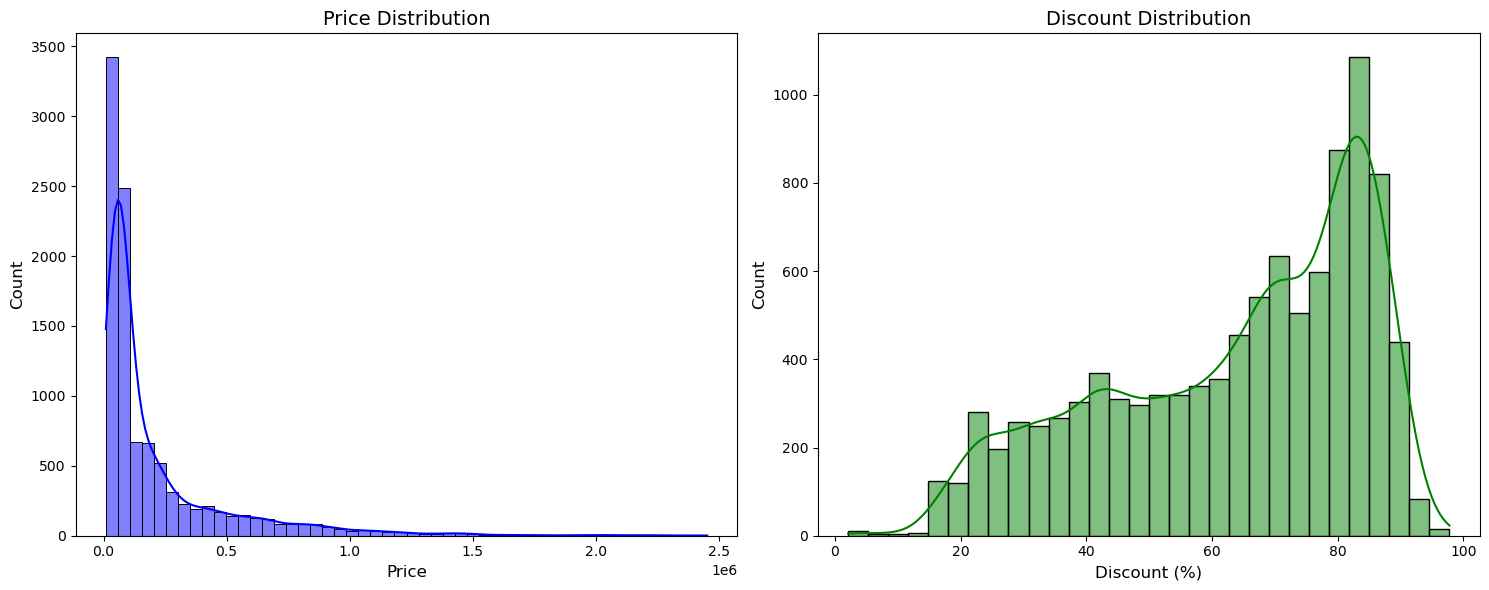

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Price Distribution
sns.histplot(df['price'], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Price Distribution', fontsize=14)
axes[0].set_xlabel('Price', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Plot 2: Discount Distribution
sns.histplot(df['discount_pct'], bins=30, kde=True, color='green', ax=axes[1])
axes[1].set_title('Discount Distribution', fontsize=14)
axes[1].set_xlabel('Discount (%)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [31]:
brand_stats = df.groupby('brand').agg({'price': ['count', 'mean', 'median', 'std'], 'rating_card': 'mean'}).round(2)
brand_stats.columns = ['Count', 'Mean_Price', 'Median_Price', 'Std_Price', 'Avg_Rating']
display(brand_stats.sort_values(('Mean_Price'), ascending=False).head(10))

,Count,Mean_Price,Median_Price,Std_Price,Avg_Rating
brand,,,,,
Thunderobot,1,973041.0,973041.0,<NA>,5.00
Msi,90,897589.38,703557.0,490671.14,4.90
Gigabyte,9,807736.33,733441.0,133293.05,4.91
Acer,95,682704.2,559348.0,476785.71,4.81
Asus,308,676040.65,583595.0,392700.75,4.85
Hp,55,640493.11,567601.0,361435.64,4.92
Colorful,1,599349.0,599349.0,<NA>,5.00
Apple,724,580856.48,501094.0,409700.74,4.84
Chuwi,15,513442.07,297234.0,400101.56,4.88


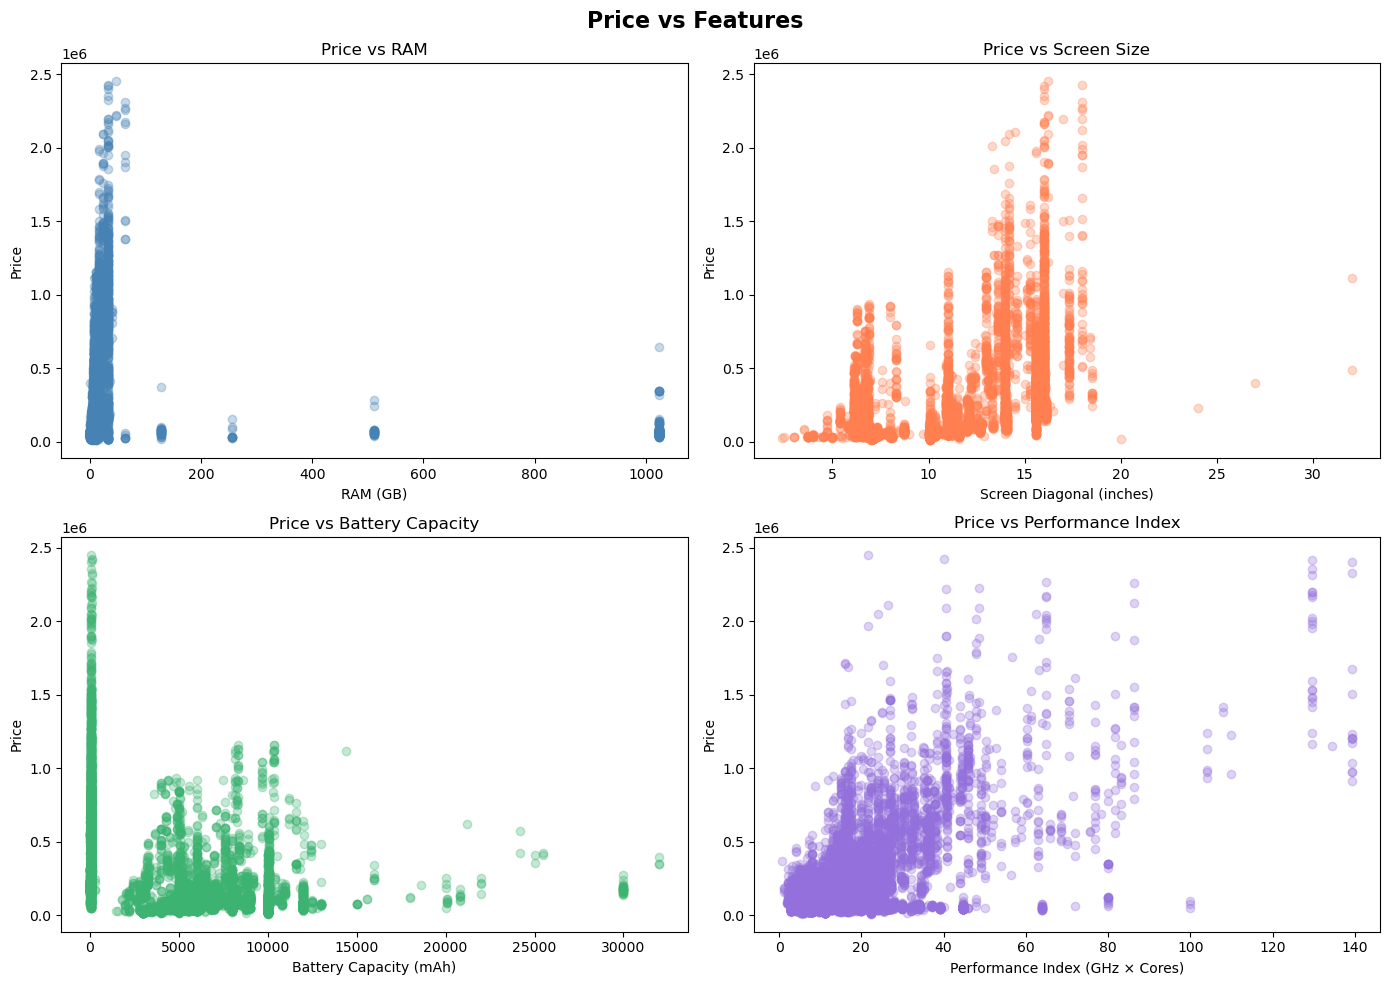

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Price vs Features', fontsize=16, fontweight='bold')
axes[0, 0].scatter(df['ram'], df['price'], alpha=0.3, color='steelblue')
axes[0, 0].set_xlabel('RAM (GB)')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Price vs RAM')

# Price vs Screen Diagonal
axes[0, 1].scatter(df['screen_diagonal'], df['price'], alpha=0.3, color='coral')
axes[0, 1].set_xlabel('Screen Diagonal (inches)')
axes[0, 1].set_ylabel('Price')
axes[0, 1].set_title('Price vs Screen Size')

# Price vs Battery Capacity
axes[1, 0].scatter(df['battery_capacity'], df['price'], alpha=0.3, color='mediumseagreen')
axes[1, 0].set_xlabel('Battery Capacity (mAh)')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Price vs Battery Capacity')

# Price vs Performance Index
axes[1, 1].scatter(df['performance_index'], df['price'], alpha=0.3, color='mediumpurple')
axes[1, 1].set_xlabel('Performance Index (GHz × Cores)')
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_title('Price vs Performance Index')

plt.tight_layout()
plt.savefig('price_vs_features.png', dpi=150)
plt.show()

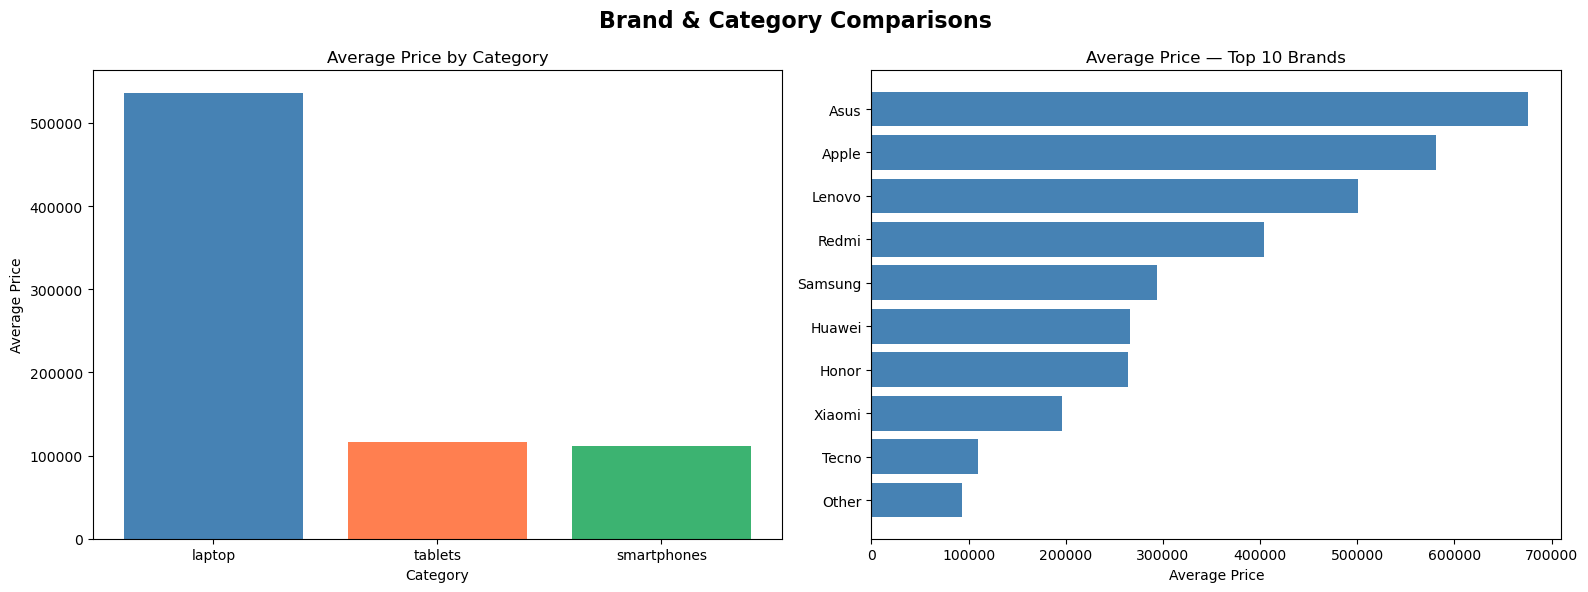

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Brand & Category Comparisons', fontsize=16, fontweight='bold')

# Average price by category
avg_price_cat = df.groupby('category')['price'].mean().sort_values(ascending=False)
axes[0].bar(avg_price_cat.index, avg_price_cat.values, color=['steelblue', 'coral', 'mediumseagreen'])
axes[0].set_title('Average Price by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Price')

# Top 10 brands by average price
top_brands = df['brand'].value_counts().head(10).index
avg_price_brand = df[df['brand'].isin(top_brands)].groupby('brand')['price'].mean().sort_values(ascending=False)
axes[1].barh(avg_price_brand.index, avg_price_brand.values, color='steelblue')
axes[1].set_title('Average Price — Top 10 Brands')
axes[1].set_xlabel('Average Price')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

C:\Users\Bereket\AppData\Local\Temp\ipykernel_1508\510294030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='price', palette='muted')


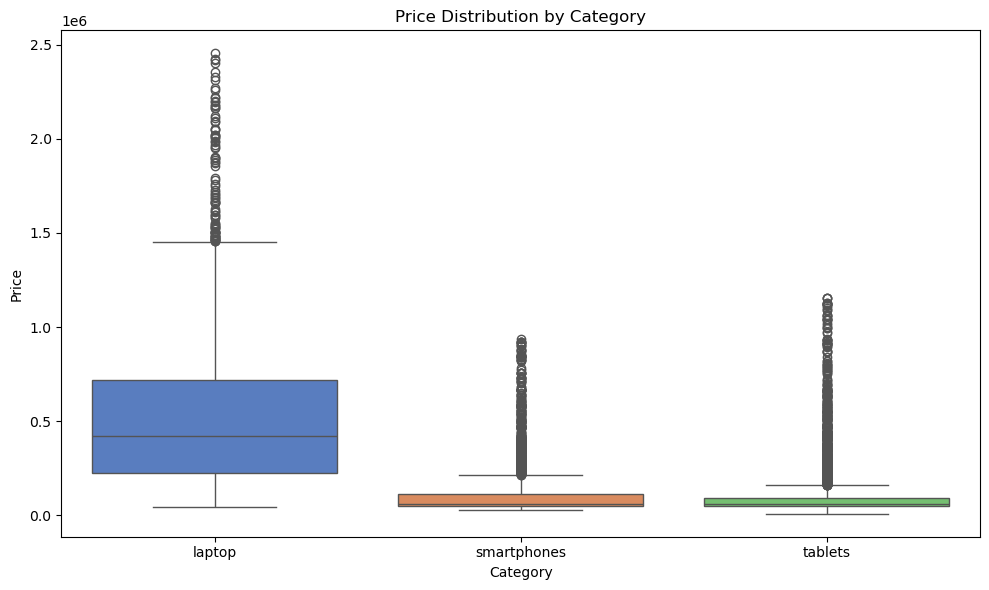

In [34]:
# Price distribution by category (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='price', palette='muted')
plt.title('Price Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

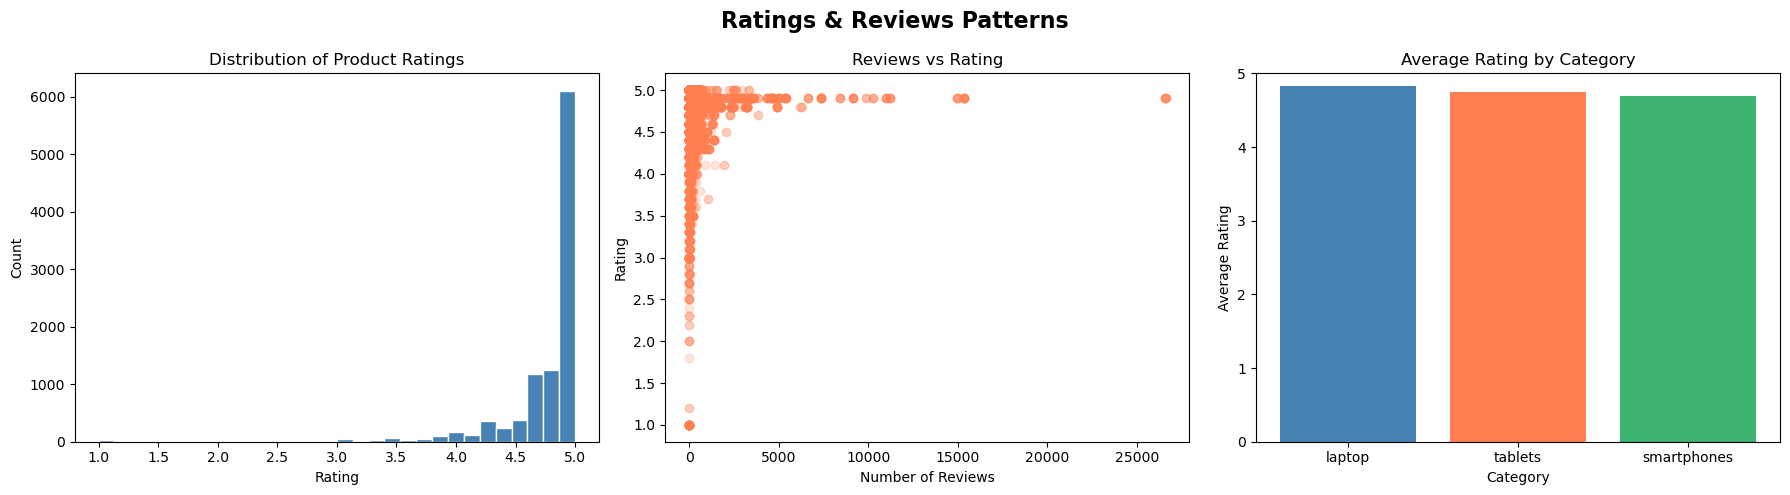

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ratings & Reviews Patterns', fontsize=16, fontweight='bold')

# Distribution of rating_card
axes[0].hist(df['rating_card'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Product Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Reviews vs Rating scatter
axes[1].scatter(df['reviews_card'], df['rating_card'], alpha=0.2, color='coral')
axes[1].set_title('Reviews vs Rating')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Rating')

# Average rating by category
avg_rating = df.groupby('category')['rating_card'].mean().sort_values(ascending=False)
axes[2].bar(avg_rating.index, avg_rating.values, color=['steelblue', 'coral', 'mediumseagreen'])
axes[2].set_title('Average Rating by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Average Rating')
axes[2].set_ylim(0, 5)

plt.tight_layout()
plt.show()

C:\Users\Bereket\AppData\Local\Temp\ipykernel_1508\2639768693.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='value_score', palette='muted', ax=axes[2])


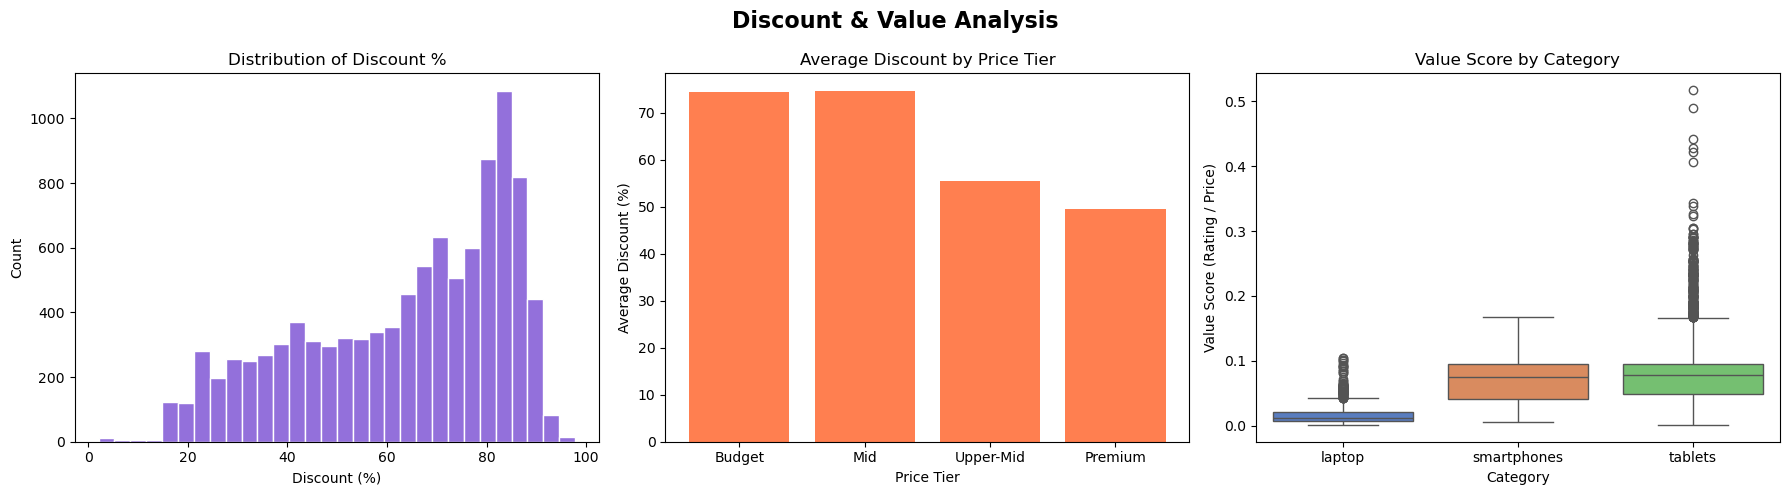

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Discount & Value Analysis', fontsize=16, fontweight='bold')

# Distribution of discount %
axes[0].hist(df['discount_pct'], bins=30, color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribution of Discount %')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Count')

# Average discount by price tier
avg_discount = df.groupby('price_tier', observed=True)['discount_pct'].mean()
axes[1].bar(avg_discount.index, avg_discount.values, color='coral')
axes[1].set_title('Average Discount by Price Tier')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Average Discount (%)')

# Value score by category (boxplot)
sns.boxplot(data=df, x='category', y='value_score', palette='muted', ax=axes[2])
axes[2].set_title('Value Score by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Value Score (Rating / Price)')

plt.tight_layout()
plt.show()

In [37]:
# sns.pairplot(df[numeric_columns].sample(min(200, len(df))))
# plt.suptitle("Pair Plot", y = 1.02)
# plt.show()

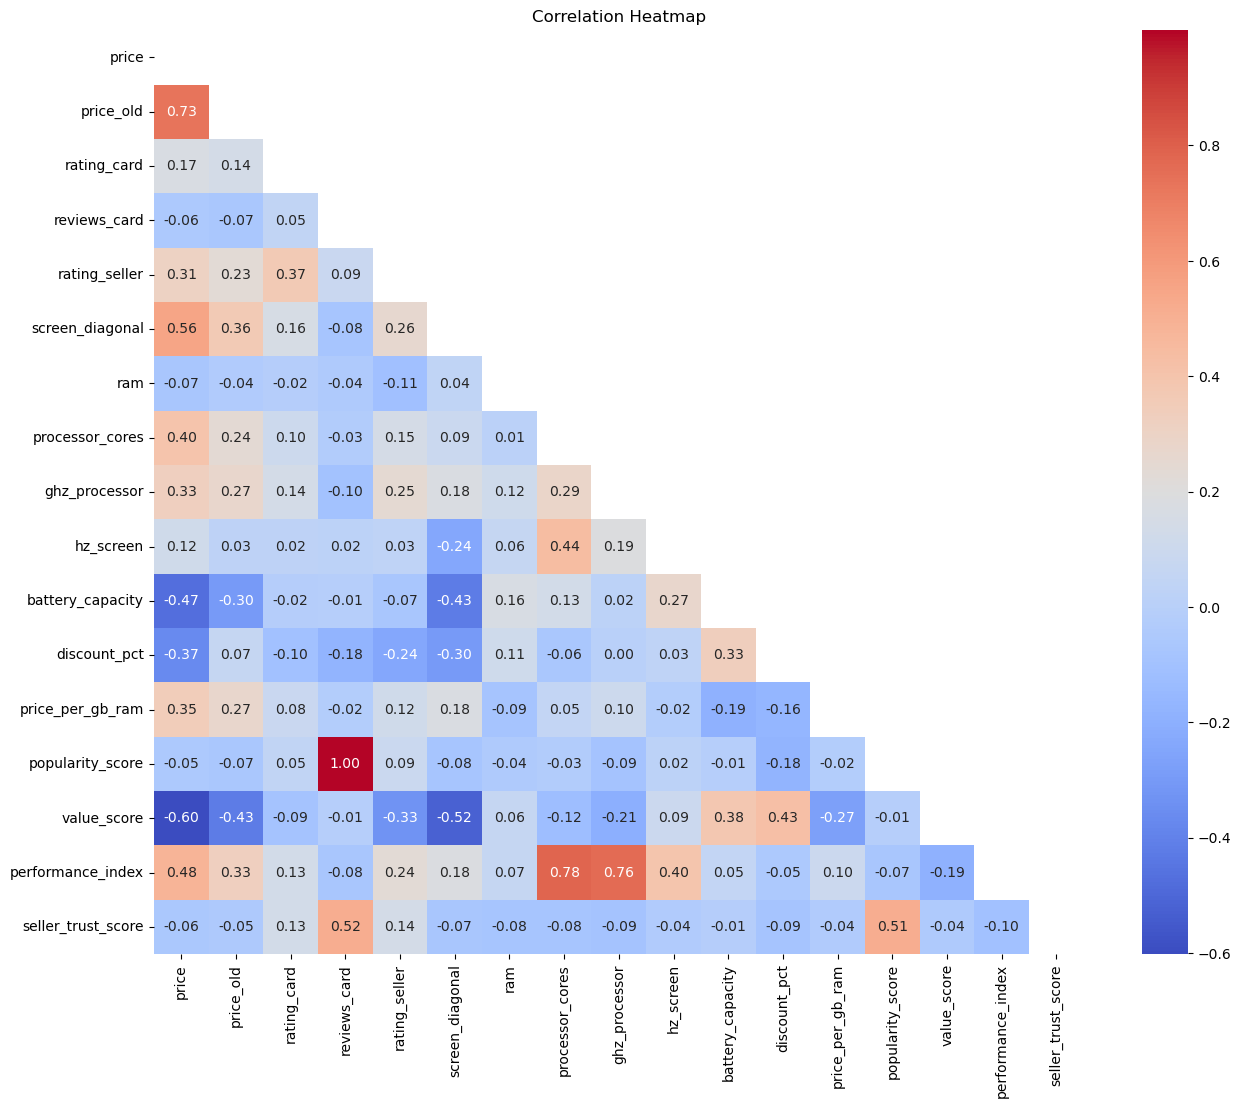

In [38]:
plt.figure(figsize=(15, 12))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm' ,mask=mask , fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

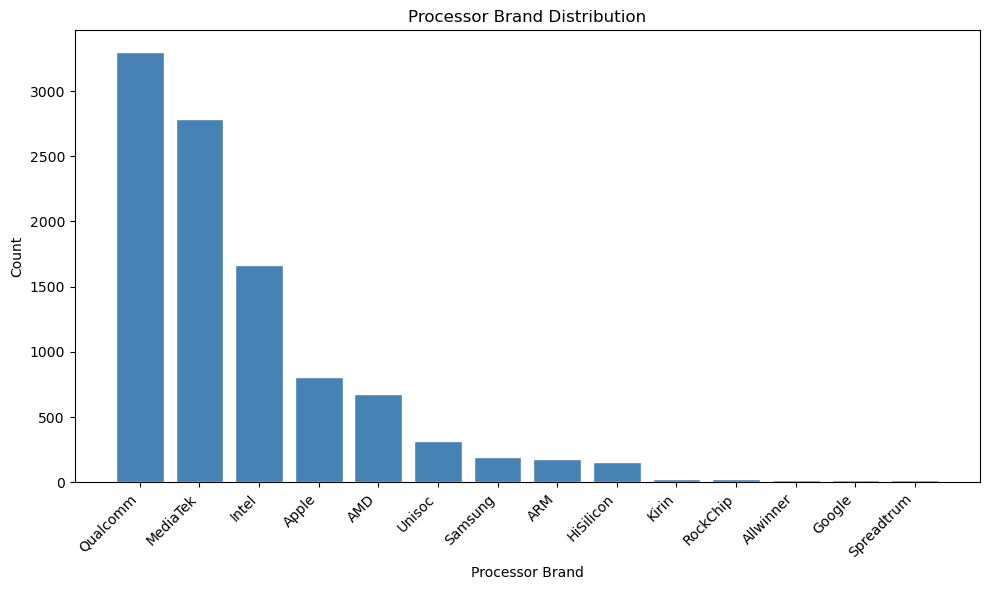

In [39]:
plt.figure(figsize=(10, 6))
processor_counts = df['processor_brand'].value_counts()
plt.bar(processor_counts.index, processor_counts.values, color='steelblue', edgecolor='white')
plt.title('Processor Brand Distribution')
plt.xlabel('Processor Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Bereket\AppData\Local\Temp\ipykernel_1508\2414460708.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='processor_brand', y='price', palette='muted')


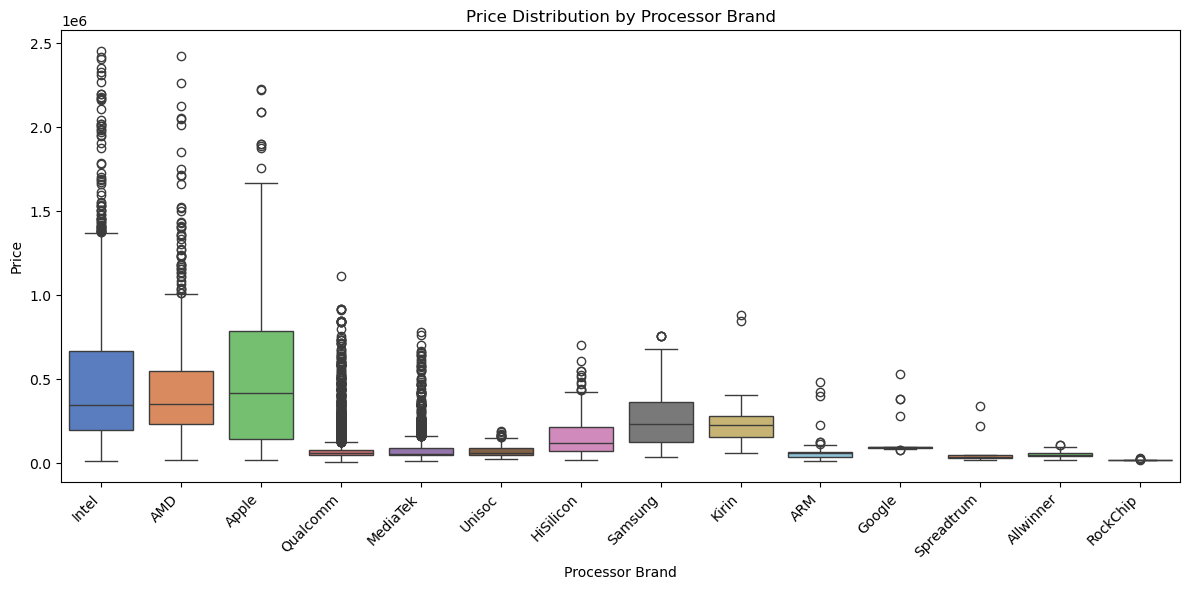

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='processor_brand', y='price', palette='muted')
plt.title('Price Distribution by Processor Brand')
plt.xlabel('Processor Brand')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

5. Hypothesis Testing & Time Series Analysis

## **-- Hypothesis Testing --**

In [41]:
import scipy.stats as stats

In [50]:
print("--- OZON DATA STATISTICAL ANALYSIS ---\n")

# ==========================================
# Hypothesis 1: Price difference between Apple and Samsung
# ==========================================
print("H1: Apple prices are significantly higher than Samsung")

apple_prices = df[df['brand'] == 'Apple']['price'].dropna()
samsung_prices = df[df['brand'] == 'Samsung']['price'].dropna()

t_stat_1, p_val_1 = stats.ttest_ind(apple_prices, samsung_prices, equal_var=False, alternative='greater')

print(f"T-statistic: {t_stat_1:.4f}")
print(f"P-value: {p_val_1}")

if p_val_1 < 0.05:
    print("Result: REJECTED H0 (Apple prices are statistically significantly higher than Samsung)\n")
else:
    print("Result: FAILED TO REJECT H0\n")


# ==========================================
# Hypothesis 2: Impact of RAM on Price
# ==========================================
print("H2: Higher RAM leads to significantly higher prices")

df_ram = df[['ram', 'price']].dropna()
corr, p_val_2 = stats.pearsonr(df_ram['ram'], df_ram['price'])

print(f"Correlation coefficient (r): {corr:.4f}")
print(f"P-value: {p_val_2}")

if p_val_2 < 0.01:
    print("Result: REJECTED H0 (Significant positive correlation between RAM and price)\n")
else:
    print("Result: FAILED TO REJECT H0\n")


# ==========================================
# Hypothesis 3: Price equality across categories (ANOVA)
# ==========================================
print("H3: Mean prices across Laptop, Smartphone, and Tablet are different")

laptops = df[df['category'].str.contains('laptop', case=False, na=False)]['price'].dropna()
smartphones = df[df['category'].str.contains('smartphone', case=False, na=False)]['price'].dropna()
tablets = df[df['category'].str.contains('tablet', case=False, na=False)]['price'].dropna()

f_stat_3, p_val_3 = stats.f_oneway(laptops, smartphones, tablets)

print(f"F-statistic: {f_stat_3:.4f}")
print(f"P-value: {p_val_3}")

if p_val_3 < 0.05:
    print("Result: REJECTED H0 (At least one category has a statistically significant difference)\n")
else:
    print("Result: FAILED TO REJECT H0\n")


# ==========================================
# Hypothesis 4: Laptops vs Smartphones (T-Test)
# ==========================================
print("H4: Mean price of Laptops == Mean price of Smartphones")

# Используем уже отфильтрованные данные из H3 для надежности
t_stat_4, p_value_4 = stats.ttest_ind(laptops, smartphones, equal_var=False)

print(f"T-statistic: {t_stat_4:.4f}")
print(f"P-value: {p_value_4}")
print(f"Mean Laptop Price:     {laptops.mean():.2f}")
print(f"Mean Smartphone Price: {smartphones.mean():.2f}")
print(f"Difference:            {abs(laptops.mean() - smartphones.mean()):.2f}")

if p_value_4 < 0.05:
    print("Result: Reject the Null Hypothesis (H0).")
    print("Interpretation: There is a statistically significant difference in mean prices between laptops and smartphones.")
else:
    print("Result: Fail to reject the Null Hypothesis (H0).")
    print("Interpretation: No significant price difference found between these categories.")

--- OZON DATA STATISTICAL ANALYSIS ---

H1: Apple prices are significantly higher than Samsung
T-statistic: 15.0675
P-value: 2.113877075868496e-47
Result: REJECTED H0 (Apple prices are statistically significantly higher than Samsung)

H2: Higher RAM leads to significantly higher prices
Correlation coefficient (r): -0.0711
P-value: 6.717989962325697e-13
Result: REJECTED H0 (Significant positive correlation between RAM and price)

H3: Mean prices across Laptop, Smartphone, and Tablet are different
F-statistic: 3013.7925
P-value: 0.0
Result: REJECTED H0 (At least one category has a statistically significant difference)

H4: Mean price of Laptops == Mean price of Smartphones
T-statistic: 50.4362
P-value: 0.0
Mean Laptop Price:     536403.23
Mean Smartphone Price: 111561.94
Difference:            424841.29
Result: Reject the Null Hypothesis (H0).
Interpretation: There is a statistically significant difference in mean prices between laptops and smartphones.


6. Predictive Modeling (Machine Learning)

## **-- ML --**

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [44]:
# 1. Prepare Features (X) and Target (y)
# Selecting numeric columns and the newly encoded features from df_encode
features = [
    'rating_card', 'reviews_card', 'rating_seller', 'screen_diagonal', 'ram',
    'processor_cores', 'ghz_processor', 'hz_screen', 'battery_capacity',
    'category_encoded', 'processor_brand_encoded', 'brand_freq_encoded'
]
# Adding the One-Hot Encoded matrix and OS columns
features += [col for col in df_encode.columns if 'matrix_' in col or 'os_' in col]

X = df_encode[features]
y = df_encode['price']

# 2. Split the dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build and Train the Baseline Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred = rf_model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Baseline Model (Random Forest) ---")
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 5. Actual vs Predicted
print(f"\n--- Prediction Sample ---")
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)}).head(10)
print(comparison.to_string(index=False))

# 6. Feature Importance
print(f"\n--- Top 10 Most Important Features ---")
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(importance_df.to_string(index=False))

--- Baseline Model (Random Forest) ---
MAE:      33905.03
RMSE:     85985.23
R² Score: 0.9095

--- Prediction Sample ---
   Actual  Predicted
  40795.0   48860.22
  40528.0   42091.71
 149890.0  149860.34
 134173.0  155355.08
 164581.0  162138.31
 367931.0  416388.87
  56135.0   55823.76
  70394.0   80874.44
 303976.0  289557.70
 789905.0  886968.47

--- Top 10 Most Important Features ---
                Feature  Importance
        screen_diagonal    0.315142
        processor_cores    0.245734
             os_Android    0.110425
                    ram    0.064744
     brand_freq_encoded    0.062121
          ghz_processor    0.058137
       battery_capacity    0.032442
processor_brand_encoded    0.030466
              hz_screen    0.024202
           reviews_card    0.013736


## **-- Advanced Model --**

In [45]:
import xgboost as xgb

In [46]:
# 1. Build and Train Advanced Model
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# 2. Evaluate Advanced Model
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

# 3. Comparison and Conclusion
print(f"{'Metric':<10} {'Random Forest':>15} {'XGBoost':>15}")
print(f"{'MAE':<10} {mae:>15.2f} {mae_xgb:>15.2f}")
print(f"{'RMSE':<10} {rmse:>15.2f} {rmse_xgb:>15.2f}")
print(f"{'R²':<10} {r2:>15.4f} {r2_xgb:>15.4f}")

if r2_xgb > r2:
    improvement = ((r2_xgb - r2) / r2) * 100
    print(f"\nXGBoost outperformed Random Forest with a {improvement:.2f}% higher R² score.")
else:
    print("\nBaseline Random Forest performed better or similar to XGBoost.")

Metric       Random Forest         XGBoost
MAE               33905.03        36145.68
RMSE              85985.23        79999.11
R²                  0.9095          0.9216

XGBoost outperformed Random Forest with a 1.34% higher R² score.
